# Exploratory Data Analysis (EDA)
## Music Prediction Dataset - Phase 1

**Dataset:** 732,988 clean songs with audio features, lyrics, and metadata

**Target Variables:**
1. Valence (mood: sad → happy)
2. Energy (intensity)
3. Danceability
4. Popularity

**Goals:**
- Understand data distributions
- Identify correlations
- Detect patterns by genre/year
- Plan feature engineering strategy

In [10]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Academic publication style settings
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)
sns.set_palette("deep")

# Configure matplotlib for publication quality
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

print("✓ Libraries loaded successfully!")
print("✓ Academic publication style configured")

✓ Libraries loaded successfully!
✓ Academic publication style configured


## 1. Load Data

In [11]:
# Load cleaned dataset
data_path = Path('../data/processed/english_ml_ready.csv')
print(f"Loading data from: {data_path}")

df = pd.read_csv(data_path)

print(f"\n✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading data from: ../data/processed/english_ml_ready.csv

✅ Dataset loaded successfully!
Shape: 550,860 rows × 20 columns

✅ Dataset loaded successfully!
Shape: 550,860 rows × 20 columns


In [12]:
# First look at the data
df.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics,year,genre,popularity
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,['HELLYEAH'],0.415,0.605,7,-11.157,1,0.0575,0.001160,0.838000,0.471,0.193,100.059,79500.0,"He said he came from Jamaica,\n he owned a cou...",2016,Rock,0
1,2ASl4wirkeYm3OWZxXKYuq,!!,NaN,Yxngxr1,0.788,0.648,7,-9.135,0,0.3150,0.900000,0.000000,0.176,0.287,79.998,114000.0,"Fucked a bitch, now she running with my kids\n...",2019,Hip-Hop,28
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,NaN,Dillinger Four,0.171,0.957,2,-5.749,1,0.1490,0.000029,0.000032,0.330,0.349,175.317,197400.0,You like to stand on the other side\n Point an...,2002,Rock,7
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,Rilès,0.823,0.612,1,-7.767,1,0.2480,0.168000,0.000000,0.109,0.688,142.959,178533.0,"It's been a while, shit I missed the rehab, ps...",2018,Hip-Hop,44
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,NaN,Rilès,0.729,0.552,7,-8.562,0,0.0650,0.183000,0.000000,0.131,0.380,86.103,186197.0,I would like to give you all my time\n I would...,2018,Hip-Hop,0


In [13]:
# Column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550860 entries, 0 to 550859
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                550860 non-null  object 
 1   name              550858 non-null  object 
 2   album_name        217481 non-null  object 
 3   artists           550860 non-null  object 
 4   danceability      550860 non-null  float64
 5   energy            550860 non-null  float64
 6   key               550860 non-null  int64  
 7   loudness          550860 non-null  float64
 8   mode              550860 non-null  int64  
 9   speechiness       550860 non-null  float64
 10  acousticness      550860 non-null  float64
 11  instrumentalness  550860 non-null  float64
 12  liveness          550860 non-null  float64
 13  valence           550860 non-null  float64
 14  tempo             550860 non-null  float64
 15  duration_ms       550860 non-null  float64
 16  lyrics            55

## 2. Basic Statistics

In [14]:
# Summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe().round(3)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year,popularity
count,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000
mean,0.527,0.671,5.275,-7.880,0.667,0.086,0.243,0.108,0.224,0.465,122.811,237403.823,2007.148,16.918
std,0.173,0.246,3.558,3.860,0.471,0.093,0.308,0.240,0.197,0.249,29.453,95536.674,13.574,16.957
min,0.046,0.000,0.000,-44.868,0.000,0.022,0.000,0.000,0.007,0.000,30.946,15027.000,1900.000,0.000
25%,0.408,0.496,2.000,-9.913,0.000,0.035,0.004,0.000,0.100,0.259,99.978,184053.000,2002.000,0.000
50%,0.530,0.716,5.000,-7.040,1.000,0.050,0.076,0.000,0.141,0.447,121.723,223000.000,2010.000,13.000
75%,0.651,0.886,8.000,-5.095,1.000,0.092,0.432,0.032,0.294,0.660,140.932,270773.000,2017.000,28.000
max,0.988,1.000,11.000,0.000,1.000,0.966,0.996,0.998,1.000,0.998,245.941,4995315.000,2025.000,91.000


In [15]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
}).sort_values('Missing', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing'] > 0])

Missing Values Summary:
            Missing  Percentage
album_name   333379       60.52
name              2        0.00


## 3. Target Variables Analysis
### Our 4 targets: Valence, Energy, Danceability, Popularity

In [16]:
# Define target variables
target_vars = ['valence', 'energy', 'danceability', 'popularity']

# Check completeness
print("Target Variables Completeness:")
for target in target_vars:
    complete = df[target].notna().sum()
    pct = (complete / len(df) * 100)
    print(f"{target:15s}: {complete:,} / {len(df):,} ({pct:.2f}%)")

Target Variables Completeness:
valence        : 550,860 / 550,860 (100.00%)
energy         : 550,860 / 550,860 (100.00%)
danceability   : 550,860 / 550,860 (100.00%)
popularity     : 550,860 / 550,860 (100.00%)


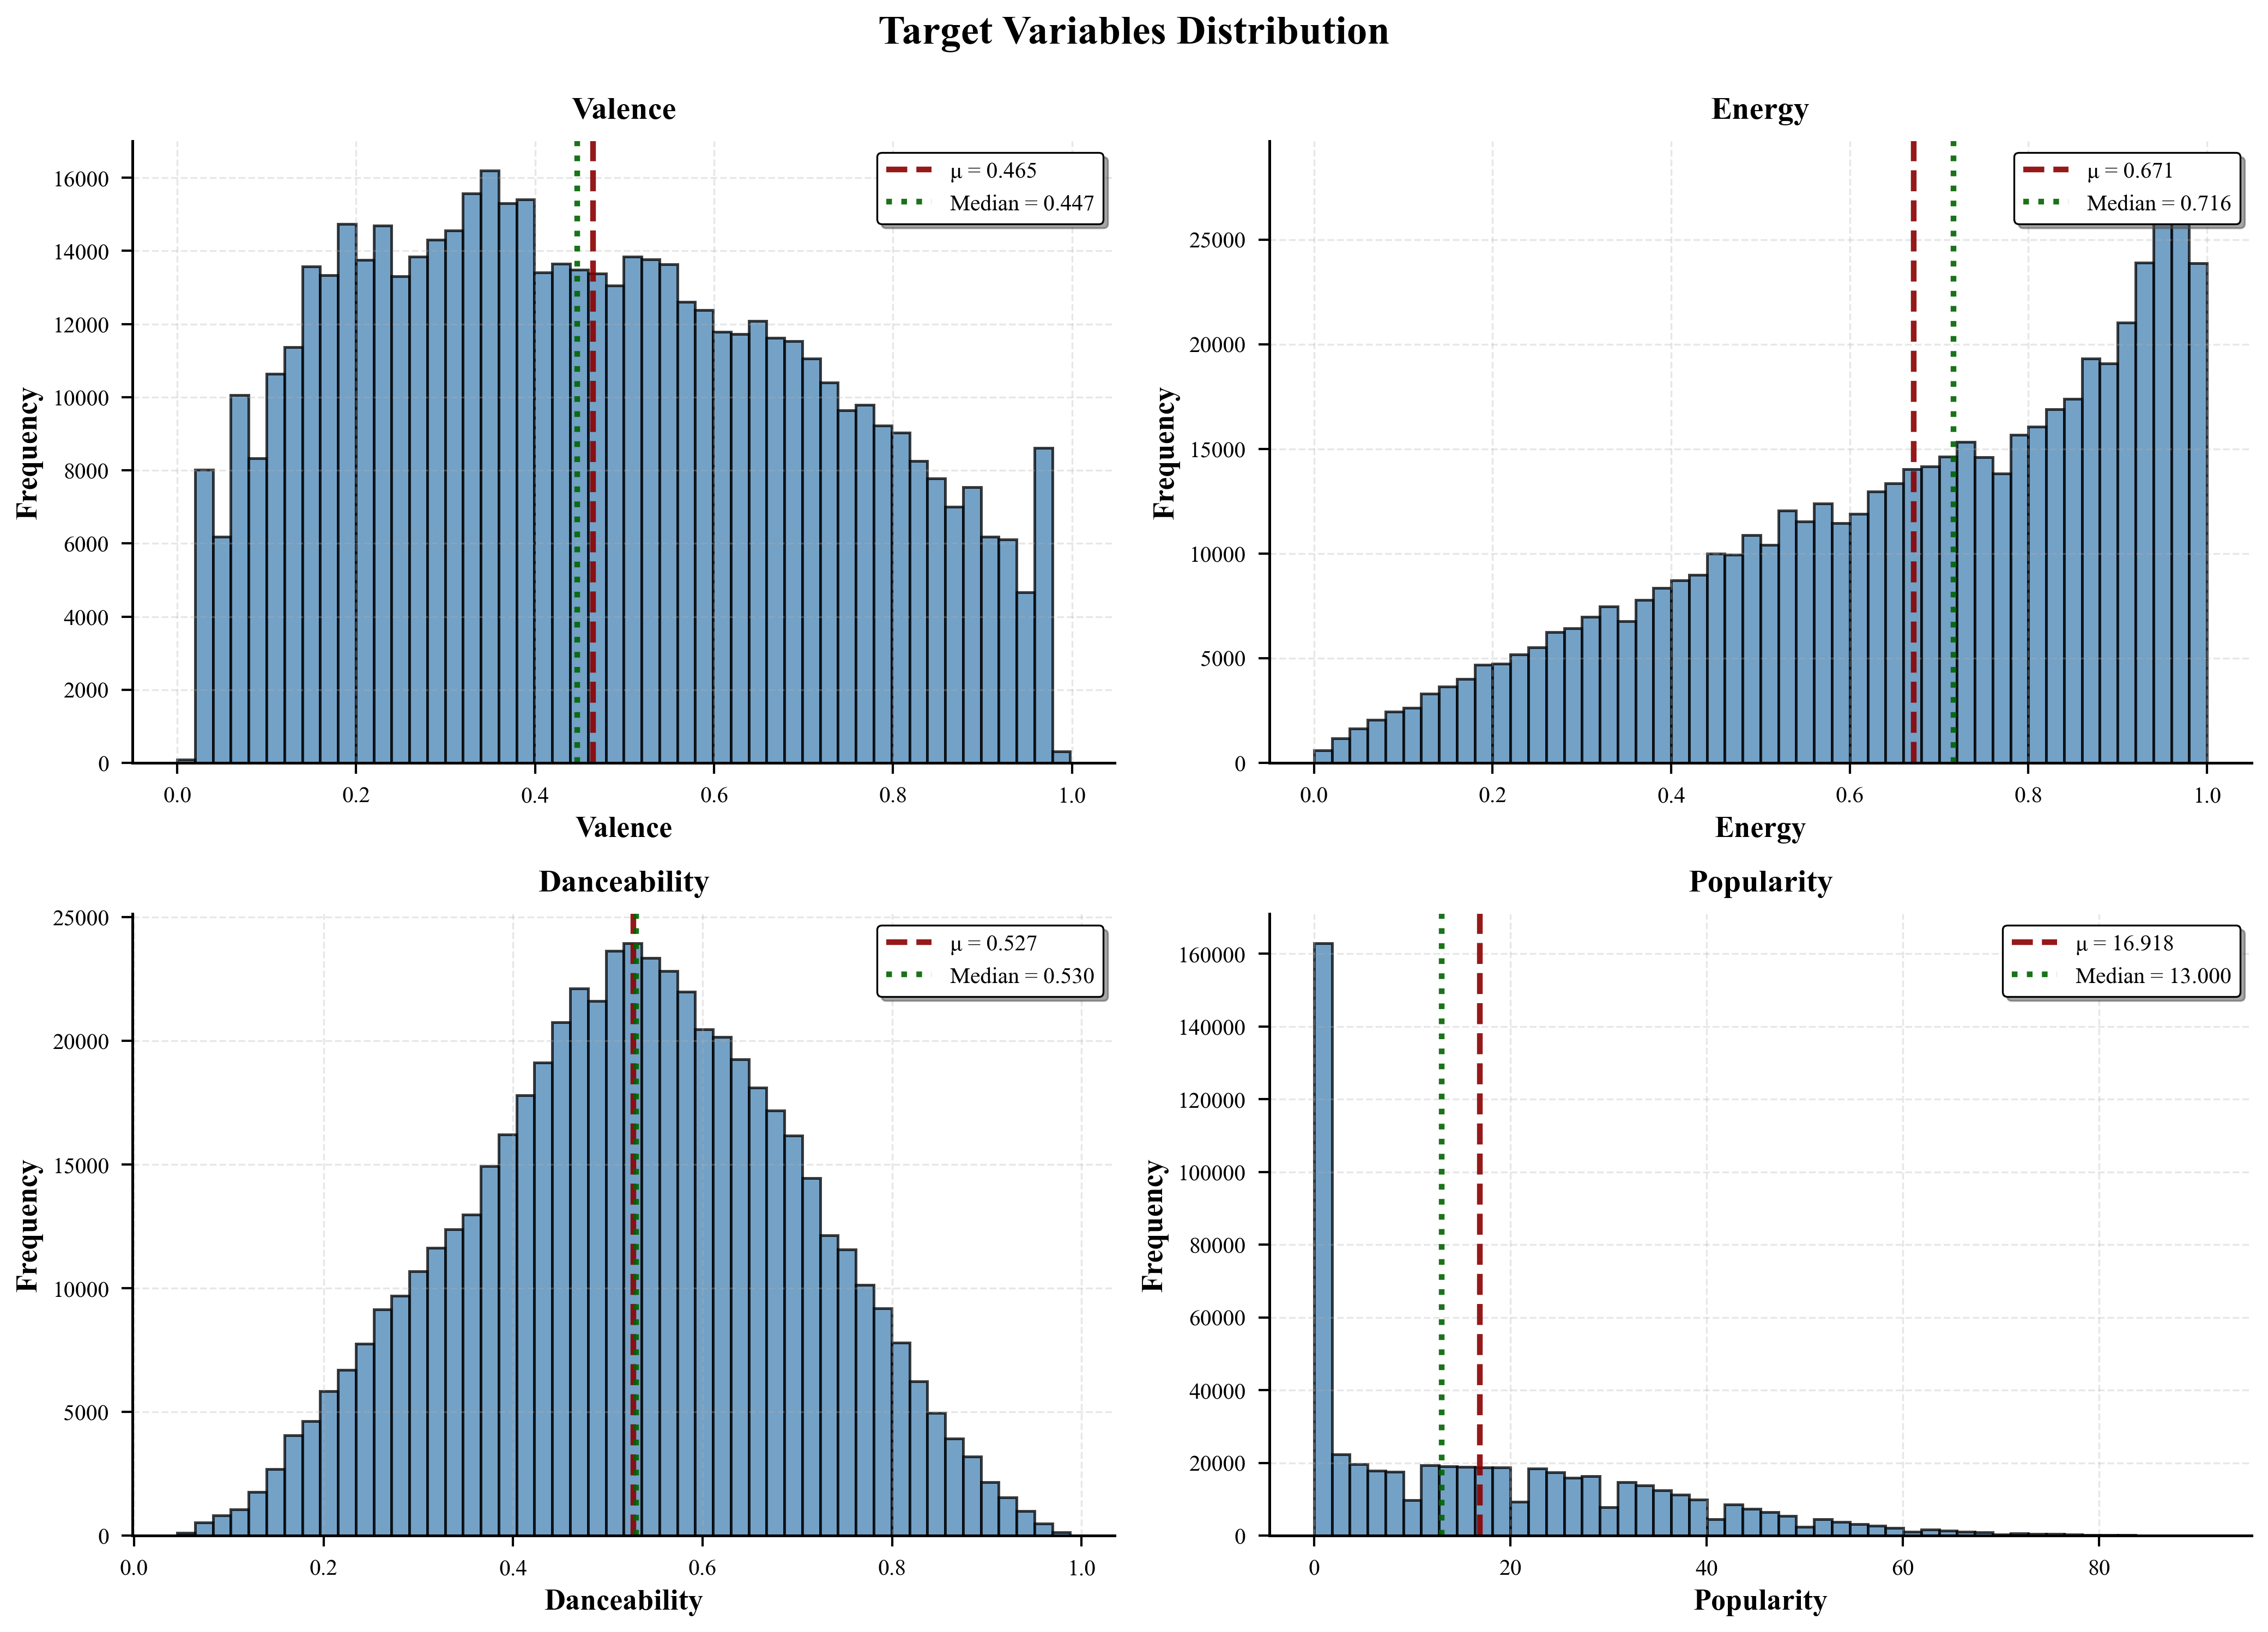


TABLE 1: Target Variables - Descriptive Statistics
                 count    mean     std    min     max   range
valence       550860.0   0.465   0.249  0.000   0.998   0.998
energy        550860.0   0.671   0.246  0.000   1.000   1.000
danceability  550860.0   0.527   0.173  0.046   0.988   0.942
popularity    550860.0  16.918  16.957  0.000  91.000  91.000


In [17]:
# Target variables distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Target Variables Distribution', fontsize=18, fontweight='bold', y=0.995)

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Histogram with academic styling
    n, bins, patches = ax.hist(df[target].dropna(), bins=50, edgecolor='black', 
                                alpha=0.75, color='steelblue', linewidth=1.2)
    
    # Statistical lines
    mean_val = df[target].mean()
    median_val = df[target].median()
    
    ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2.5, 
               label=f'μ = {mean_val:.3f}', alpha=0.9)
    ax.axvline(median_val, color='darkgreen', linestyle=':', linewidth=2.5, 
               label=f'Median = {median_val:.3f}', alpha=0.9)
    
    ax.set_xlabel(target.capitalize(), fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=13, fontweight='bold')
    ax.set_title(f'{target.capitalize()}', fontsize=14, fontweight='bold', pad=10)
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

# Create directory if it doesn't exist
from pathlib import Path
Path('../results/figures/eda').mkdir(parents=True, exist_ok=True)

plt.savefig('../results/figures/eda/target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistics table with formatting
print("\n" + "="*80)
print("TABLE 1: Target Variables - Descriptive Statistics")
print("="*80)
stats_df = df[target_vars].describe().T
stats_df['range'] = stats_df['max'] - stats_df['min']
stats_df = stats_df[['count', 'mean', 'std', 'min', 'max', 'range']]
print(stats_df.round(3).to_string())
print("="*80)

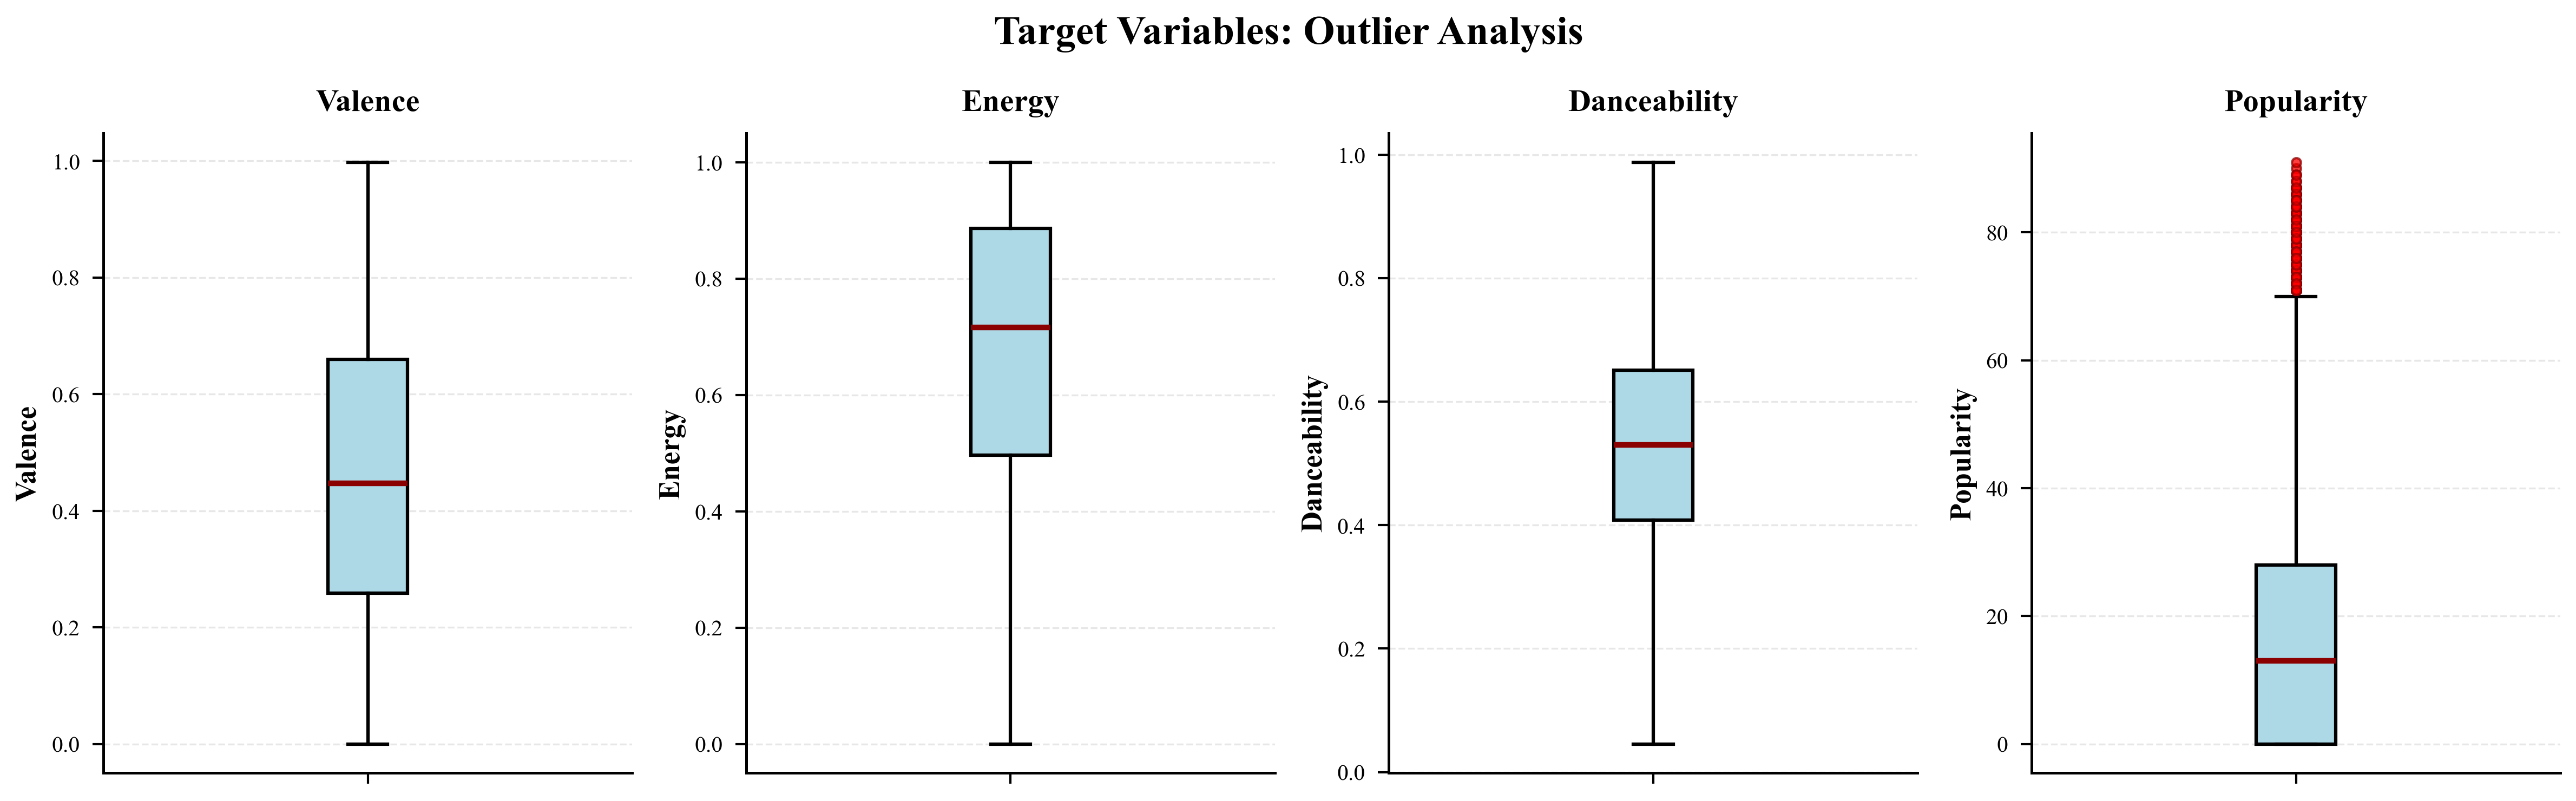

In [18]:
# Box plots for targets - Academic style
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Target Variables: Outlier Analysis', fontsize=18, fontweight='bold', y=0.98)

for idx, target in enumerate(target_vars):
    bp = axes[idx].boxplot(df[target].dropna(), vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                           medianprops=dict(color='darkred', linewidth=2.5),
                           whiskerprops=dict(color='black', linewidth=1.5),
                           capprops=dict(color='black', linewidth=1.5),
                           flierprops=dict(marker='o', markerfacecolor='red', markersize=4, 
                                          alpha=0.5, markeredgecolor='darkred'))
    
    axes[idx].set_ylabel(target.capitalize(), fontsize=13, fontweight='bold')
    axes[idx].set_title(f'{target.capitalize()}', fontsize=14, fontweight='bold', pad=10)
    axes[idx].grid(True, alpha=0.3, axis='y', linestyle='--')
    axes[idx].set_xticklabels([''])
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/eda/target_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Audio Features Analysis
### Features that will be used for prediction

In [19]:
# Define audio features
audio_features = [
    'acousticness', 'instrumentalness', 'liveness', 'speechiness',
    'loudness', 'tempo', 'duration_ms', 'key', 'mode'
]

print("Audio Features Summary:")
df[audio_features].describe().round(3)

Audio Features Summary:


,acousticness,instrumentalness,liveness,speechiness,loudness,tempo,duration_ms,key,mode
count,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000,550860.000
mean,0.243,0.108,0.224,0.086,-7.880,122.811,237403.823,5.275,0.667
std,0.308,0.240,0.197,0.093,3.860,29.453,95536.674,3.558,0.471
min,0.000,0.000,0.007,0.022,-44.868,30.946,15027.000,0.000,0.000
25%,0.004,0.000,0.100,0.035,-9.913,99.978,184053.000,2.000,0.000
50%,0.076,0.000,0.141,0.050,-7.040,121.723,223000.000,5.000,1.000
75%,0.432,0.032,0.294,0.092,-5.095,140.932,270773.000,8.000,1.000
max,0.996,0.998,1.000,0.966,0.000,245.941,4995315.000,11.000,1.000


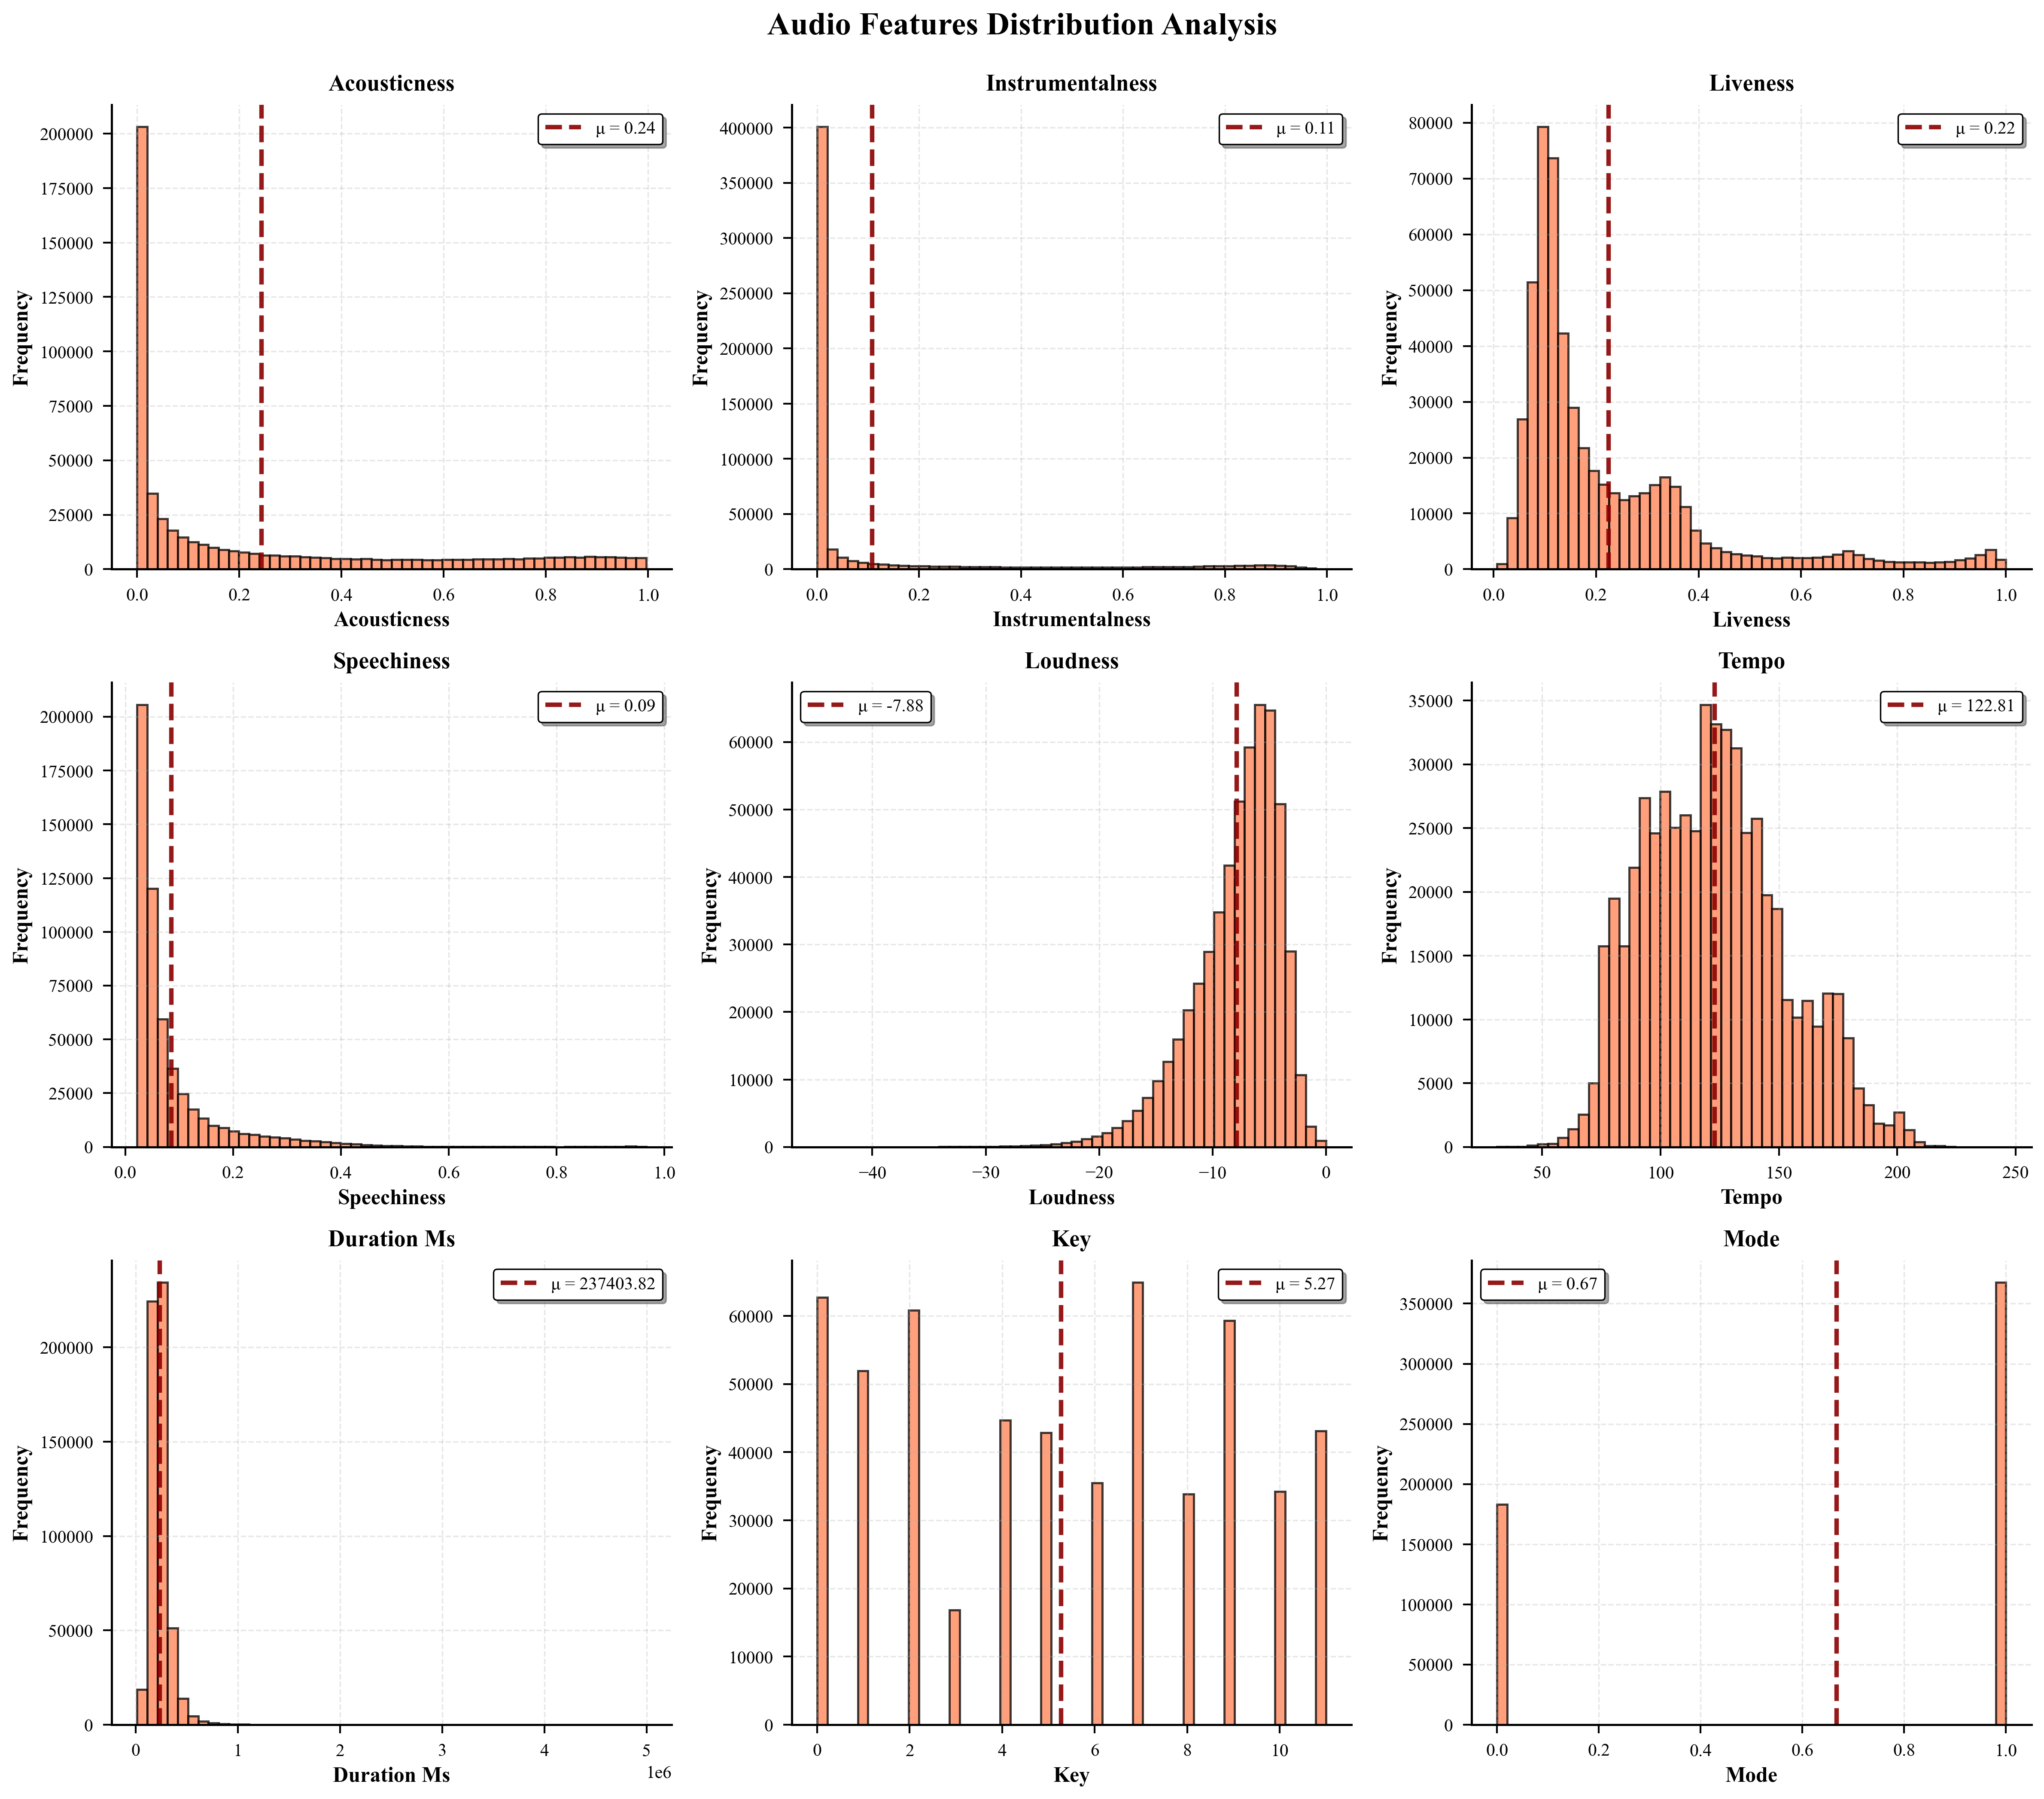

In [20]:
# Audio features distributions - Academic publication style
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Audio Features Distribution Analysis', fontsize=18, fontweight='bold', y=0.995)

for idx, feature in enumerate(audio_features):
    ax = axes[idx // 3, idx % 3]
    
    # Histogram
    ax.hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.75, 
            color='coral', linewidth=1.2)
    
    # Mean line
    mean_val = df[feature].mean()
    ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2.5, 
               label=f'μ = {mean_val:.2f}', alpha=0.9)
    
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'{feature.replace("_", " ").title()}', fontsize=13, fontweight='bold', pad=8)
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/eda/audio_features_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis
### How do features relate to our targets?

In [21]:
# Convert key and mode to numeric (they might be stored as strings)
# This ensures correlation analysis works correctly
df['key'] = pd.to_numeric(df['key'], errors='coerce')
df['mode'] = pd.to_numeric(df['mode'], errors='coerce')

print("Data types after conversion:")
print(f"key: {df['key'].dtype}")
print(f"mode: {df['mode'].dtype}")
print(f"\nSample key values: {df['key'].unique()[:15]}")
print(f"Sample mode values: {df['mode'].unique()}")

Data types after conversion:
key: int64
mode: int64

Sample key values: [ 7  2  1  9  4  6  8  0  3  5 10 11]
Sample mode values: [1 0]


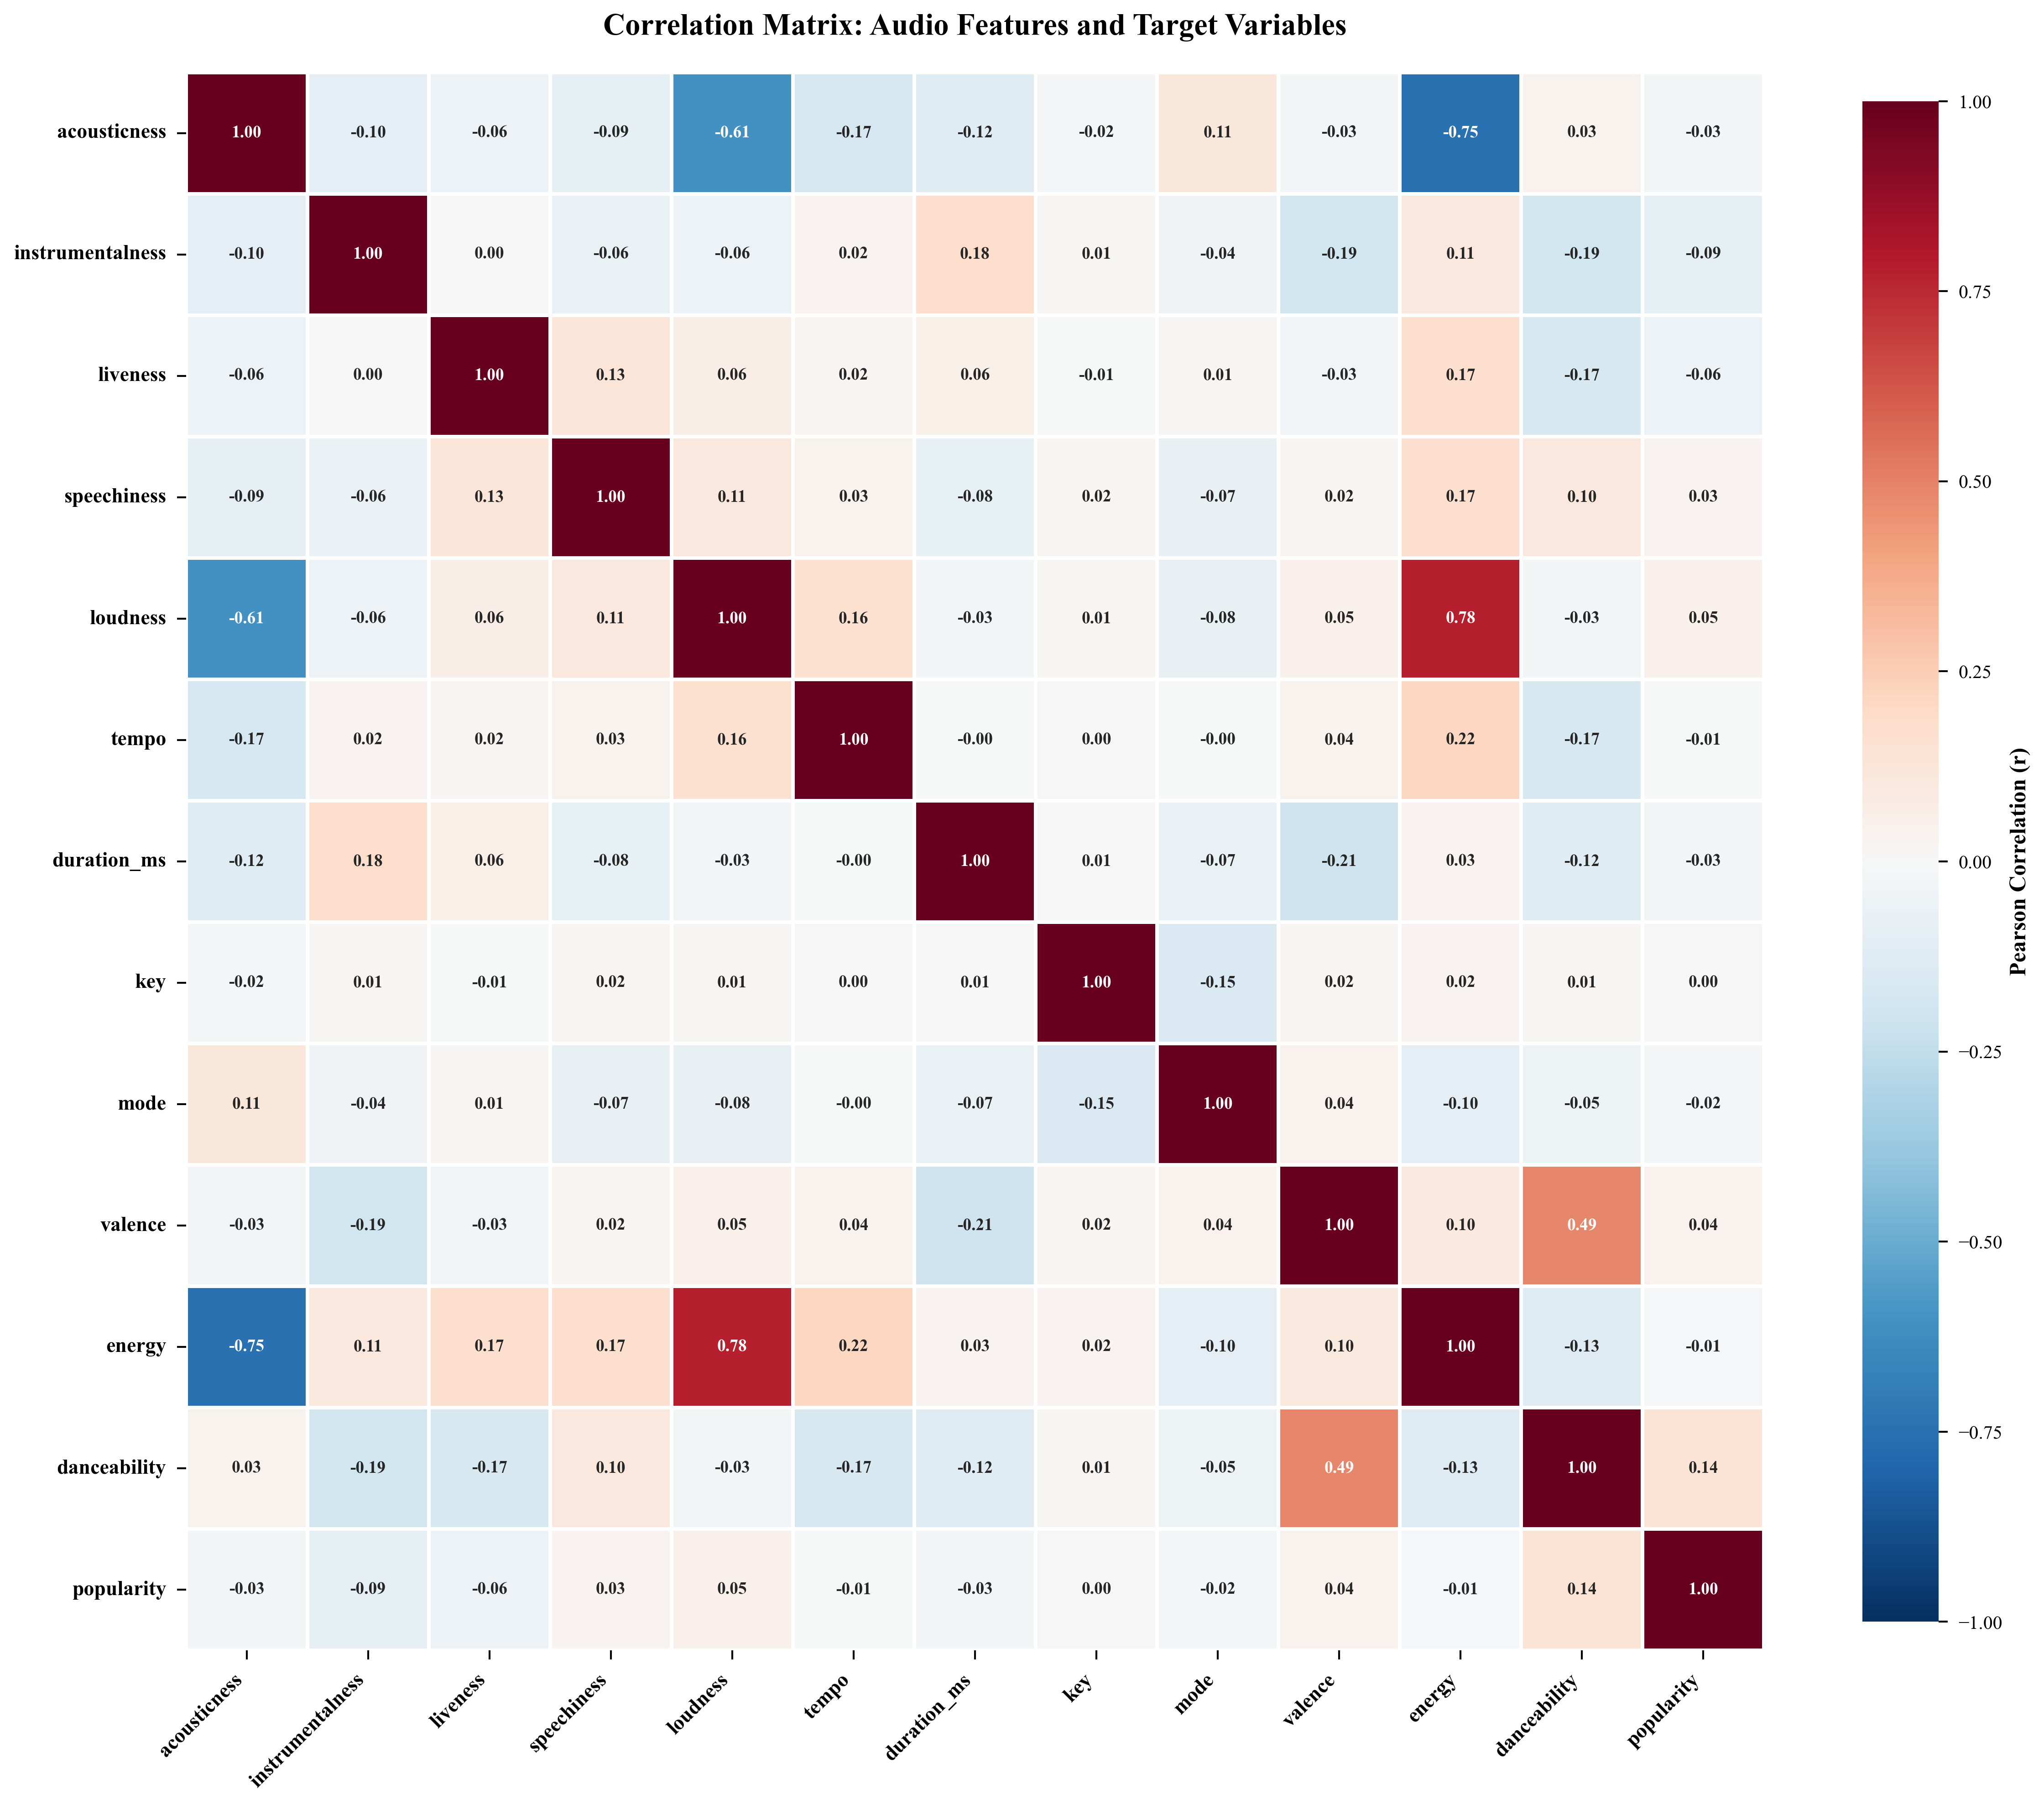

In [22]:
# Correlation matrix: All numeric features - Academic style
correlation_cols = audio_features + target_vars
corr_matrix = df[correlation_cols].corr()

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1.5, linecolor='white',
            cbar_kws={"shrink": 0.85, "label": "Pearson Correlation (r)"},
            annot_kws={"fontsize": 9, "weight": "bold"},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Matrix: Audio Features and Target Variables', 
             fontsize=16, fontweight='bold', pad=20)

# Bold labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, fontweight='bold', rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontweight='bold', rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/eda/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

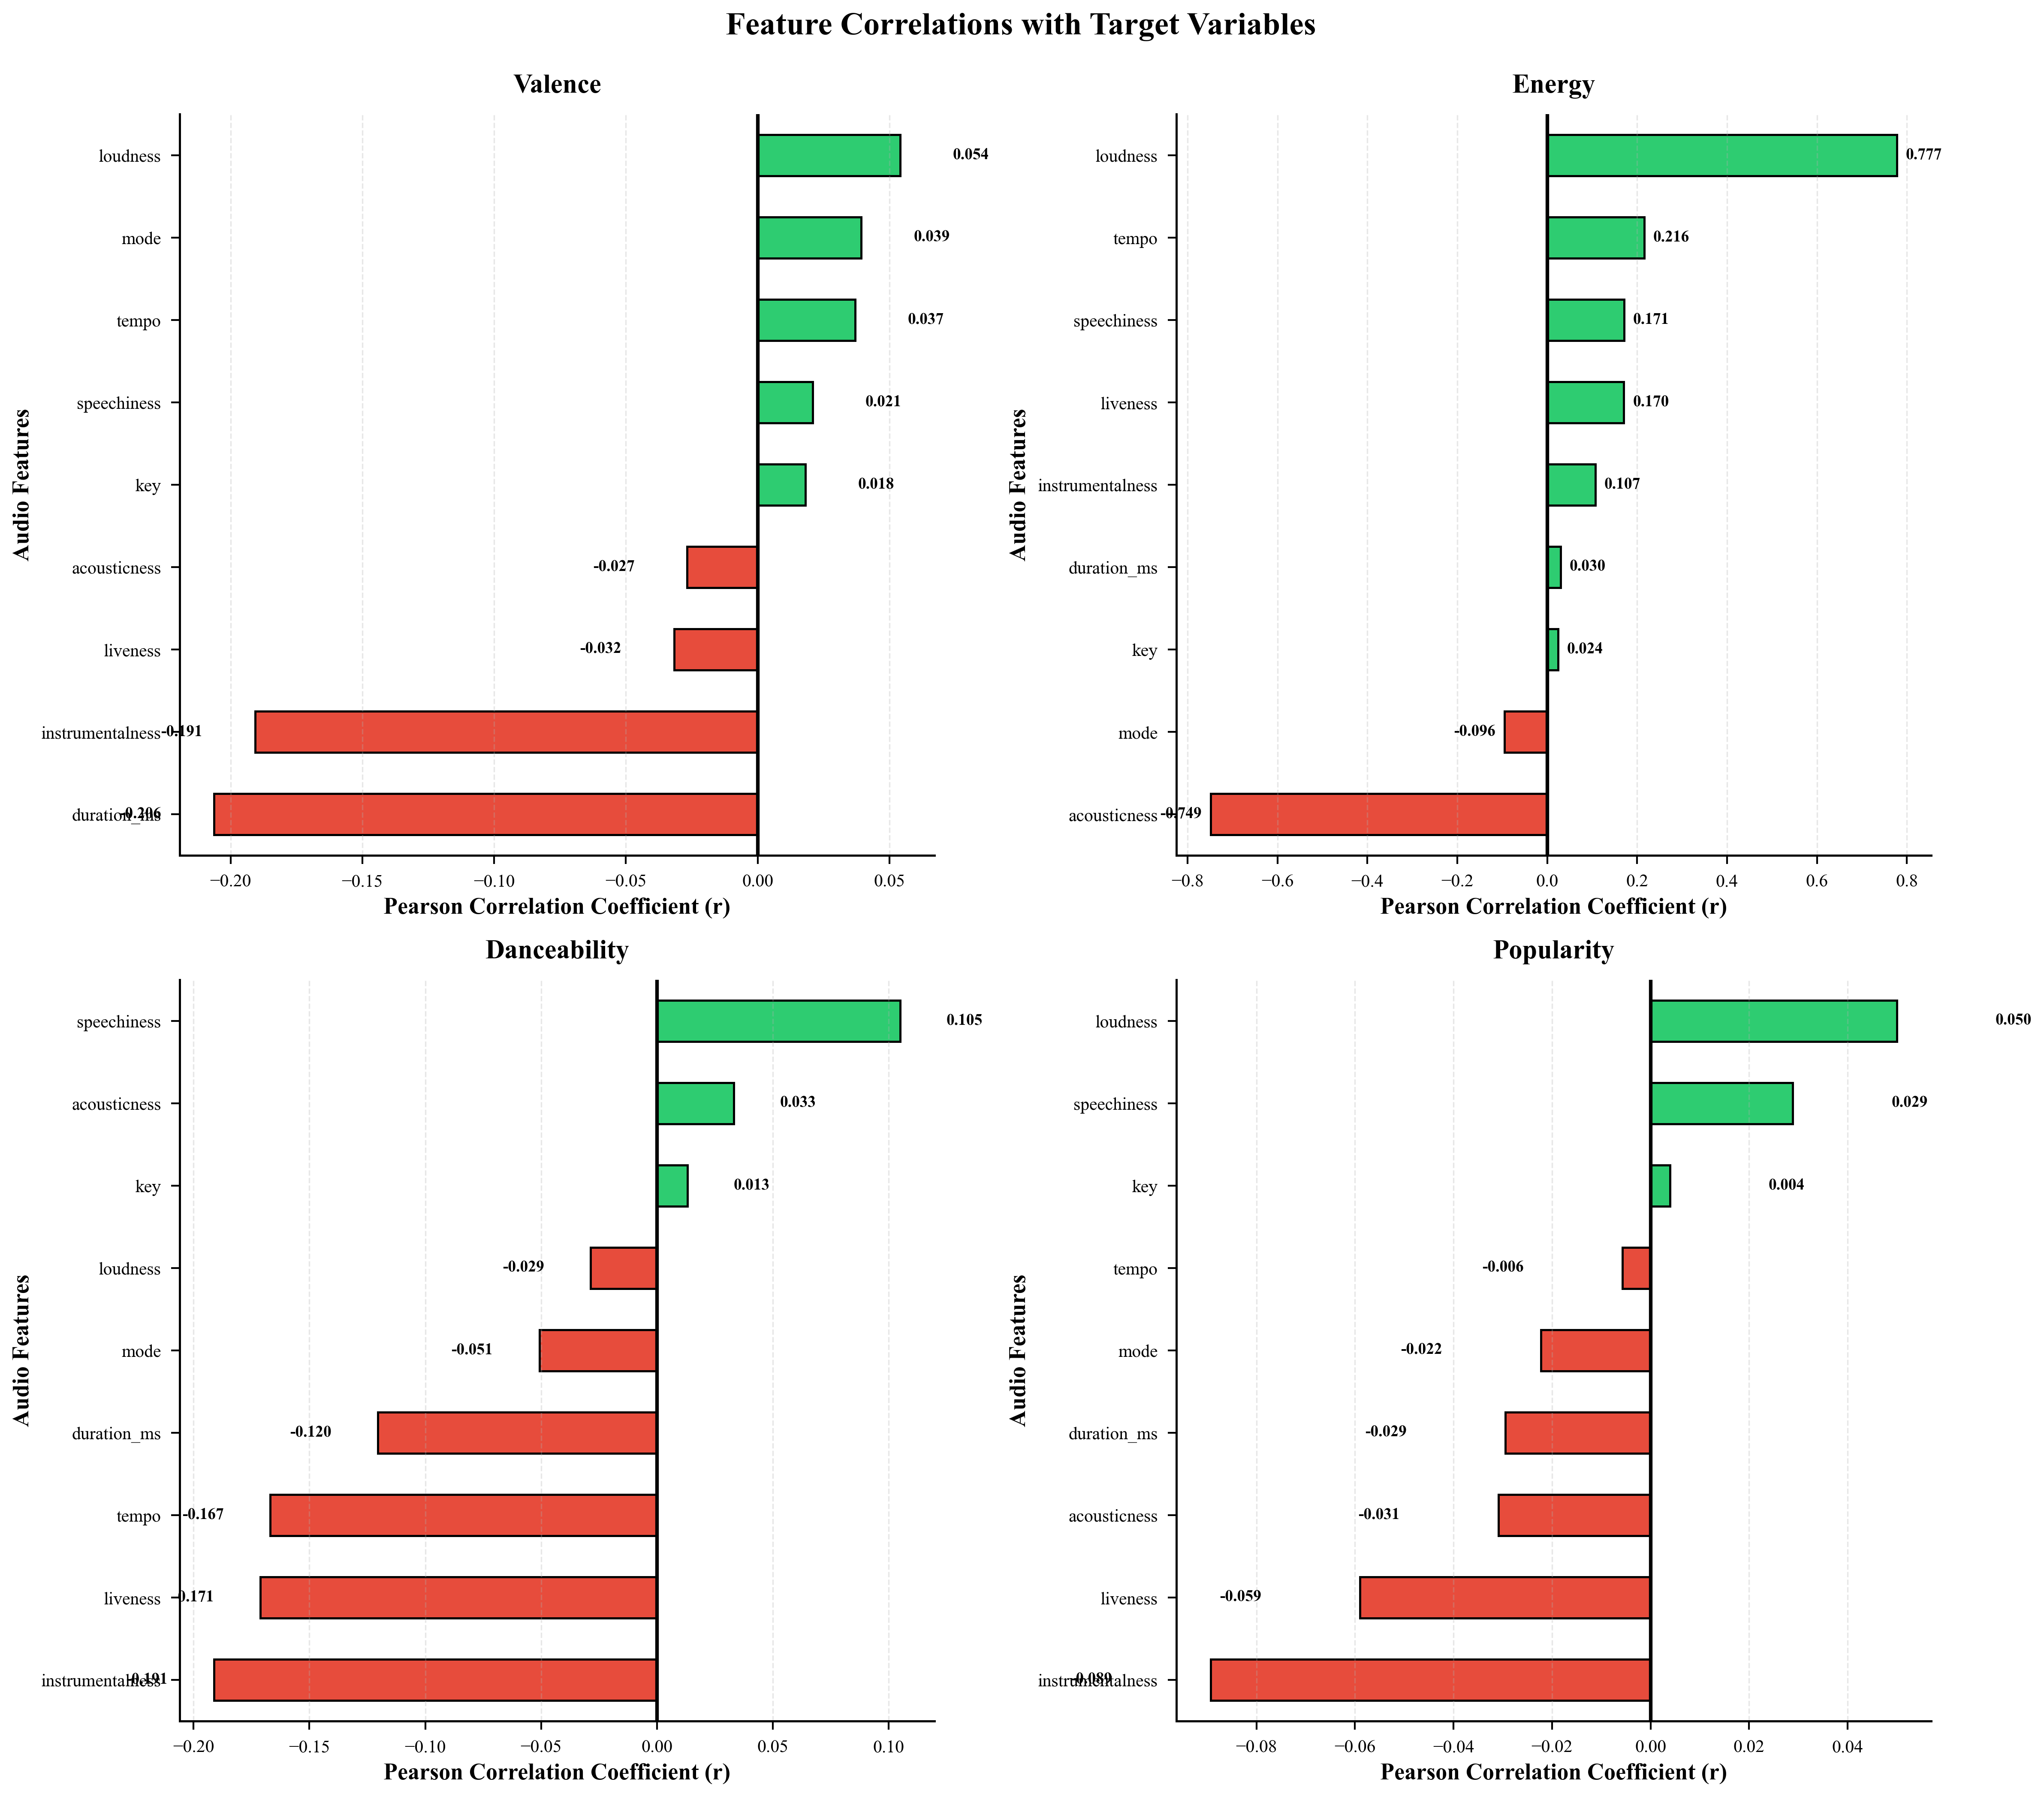


TABLE 2: Top Correlations with Target Variables

VALENCE:
  Top 3 Positive: {'loudness': 0.054030969792954874, 'mode': 0.039227619058098594, 'tempo': 0.03694373784225109}
  Top 3 Negative: {'liveness': -0.031695247758079484, 'instrumentalness': -0.190693982305111, 'duration_ms': -0.2062933387203026}

VALENCE:
  Top 3 Positive: {'loudness': 0.054030969792954874, 'mode': 0.039227619058098594, 'tempo': 0.03694373784225109}
  Top 3 Negative: {'liveness': -0.031695247758079484, 'instrumentalness': -0.190693982305111, 'duration_ms': -0.2062933387203026}

ENERGY:
  Top 3 Positive: {'loudness': 0.7774266638648322, 'tempo': 0.2155416514761899, 'speechiness': 0.17067421291264603}
  Top 3 Negative: {'key': 0.024070037412281153, 'mode': -0.09555640750634156, 'acousticness': -0.7487147262844217}

ENERGY:
  Top 3 Positive: {'loudness': 0.7774266638648322, 'tempo': 0.2155416514761899, 'speechiness': 0.17067421291264603}
  Top 3 Negative: {'key': 0.024070037412281153, 'mode': -0.09555640750634156, 'a

In [23]:
# Correlation with each target (separate analysis) - Academic style
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Feature Correlations with Target Variables', fontsize=18, fontweight='bold', y=0.995)

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Get correlations with this target
    target_corr = df[audio_features + [target]].corr()[target].drop(target).sort_values(ascending=True)
    
    # Color coding
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr.values]
    
    # Horizontal bar plot
    bars = target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=1.2)
    
    ax.set_xlabel('Pearson Correlation Coefficient (r)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Audio Features', fontsize=13, fontweight='bold')
    ax.set_title(f'{target.capitalize()}', fontsize=15, fontweight='bold', pad=12)
    ax.axvline(0, color='black', linewidth=2)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels on bars
    for i, (feature, value) in enumerate(target_corr.items()):
        x_pos = value + (0.02 if value > 0 else -0.02)
        ha = 'left' if value > 0 else 'right'
        ax.text(x_pos, i, f'{value:.3f}', va='center', ha=ha, 
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/eda/target_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top correlations for each target
print("\n" + "="*80)
print("TABLE 2: Top Correlations with Target Variables")
print("="*80)
for target in target_vars:
    target_corr = df[audio_features + [target]].corr()[target].drop(target).sort_values(ascending=False)
    print(f"\n{target.upper()}:")
    print(f"  Top 3 Positive: {target_corr.head(3).to_dict()}")
    print(f"  Top 3 Negative: {target_corr.tail(3).to_dict()}")
print("="*80)

## 6. Genre Analysis
### How do targets vary by genre?

Total unique genres: 10

Top 10 genres:
genre
Rock          197195
Pop            72592
Electronic     69775
Folk           50849
Country        46172
Hip-Hop        41765
R&B            27344
Jazz           17011
Blues          15977
Classical      12180
Name: count, dtype: int64


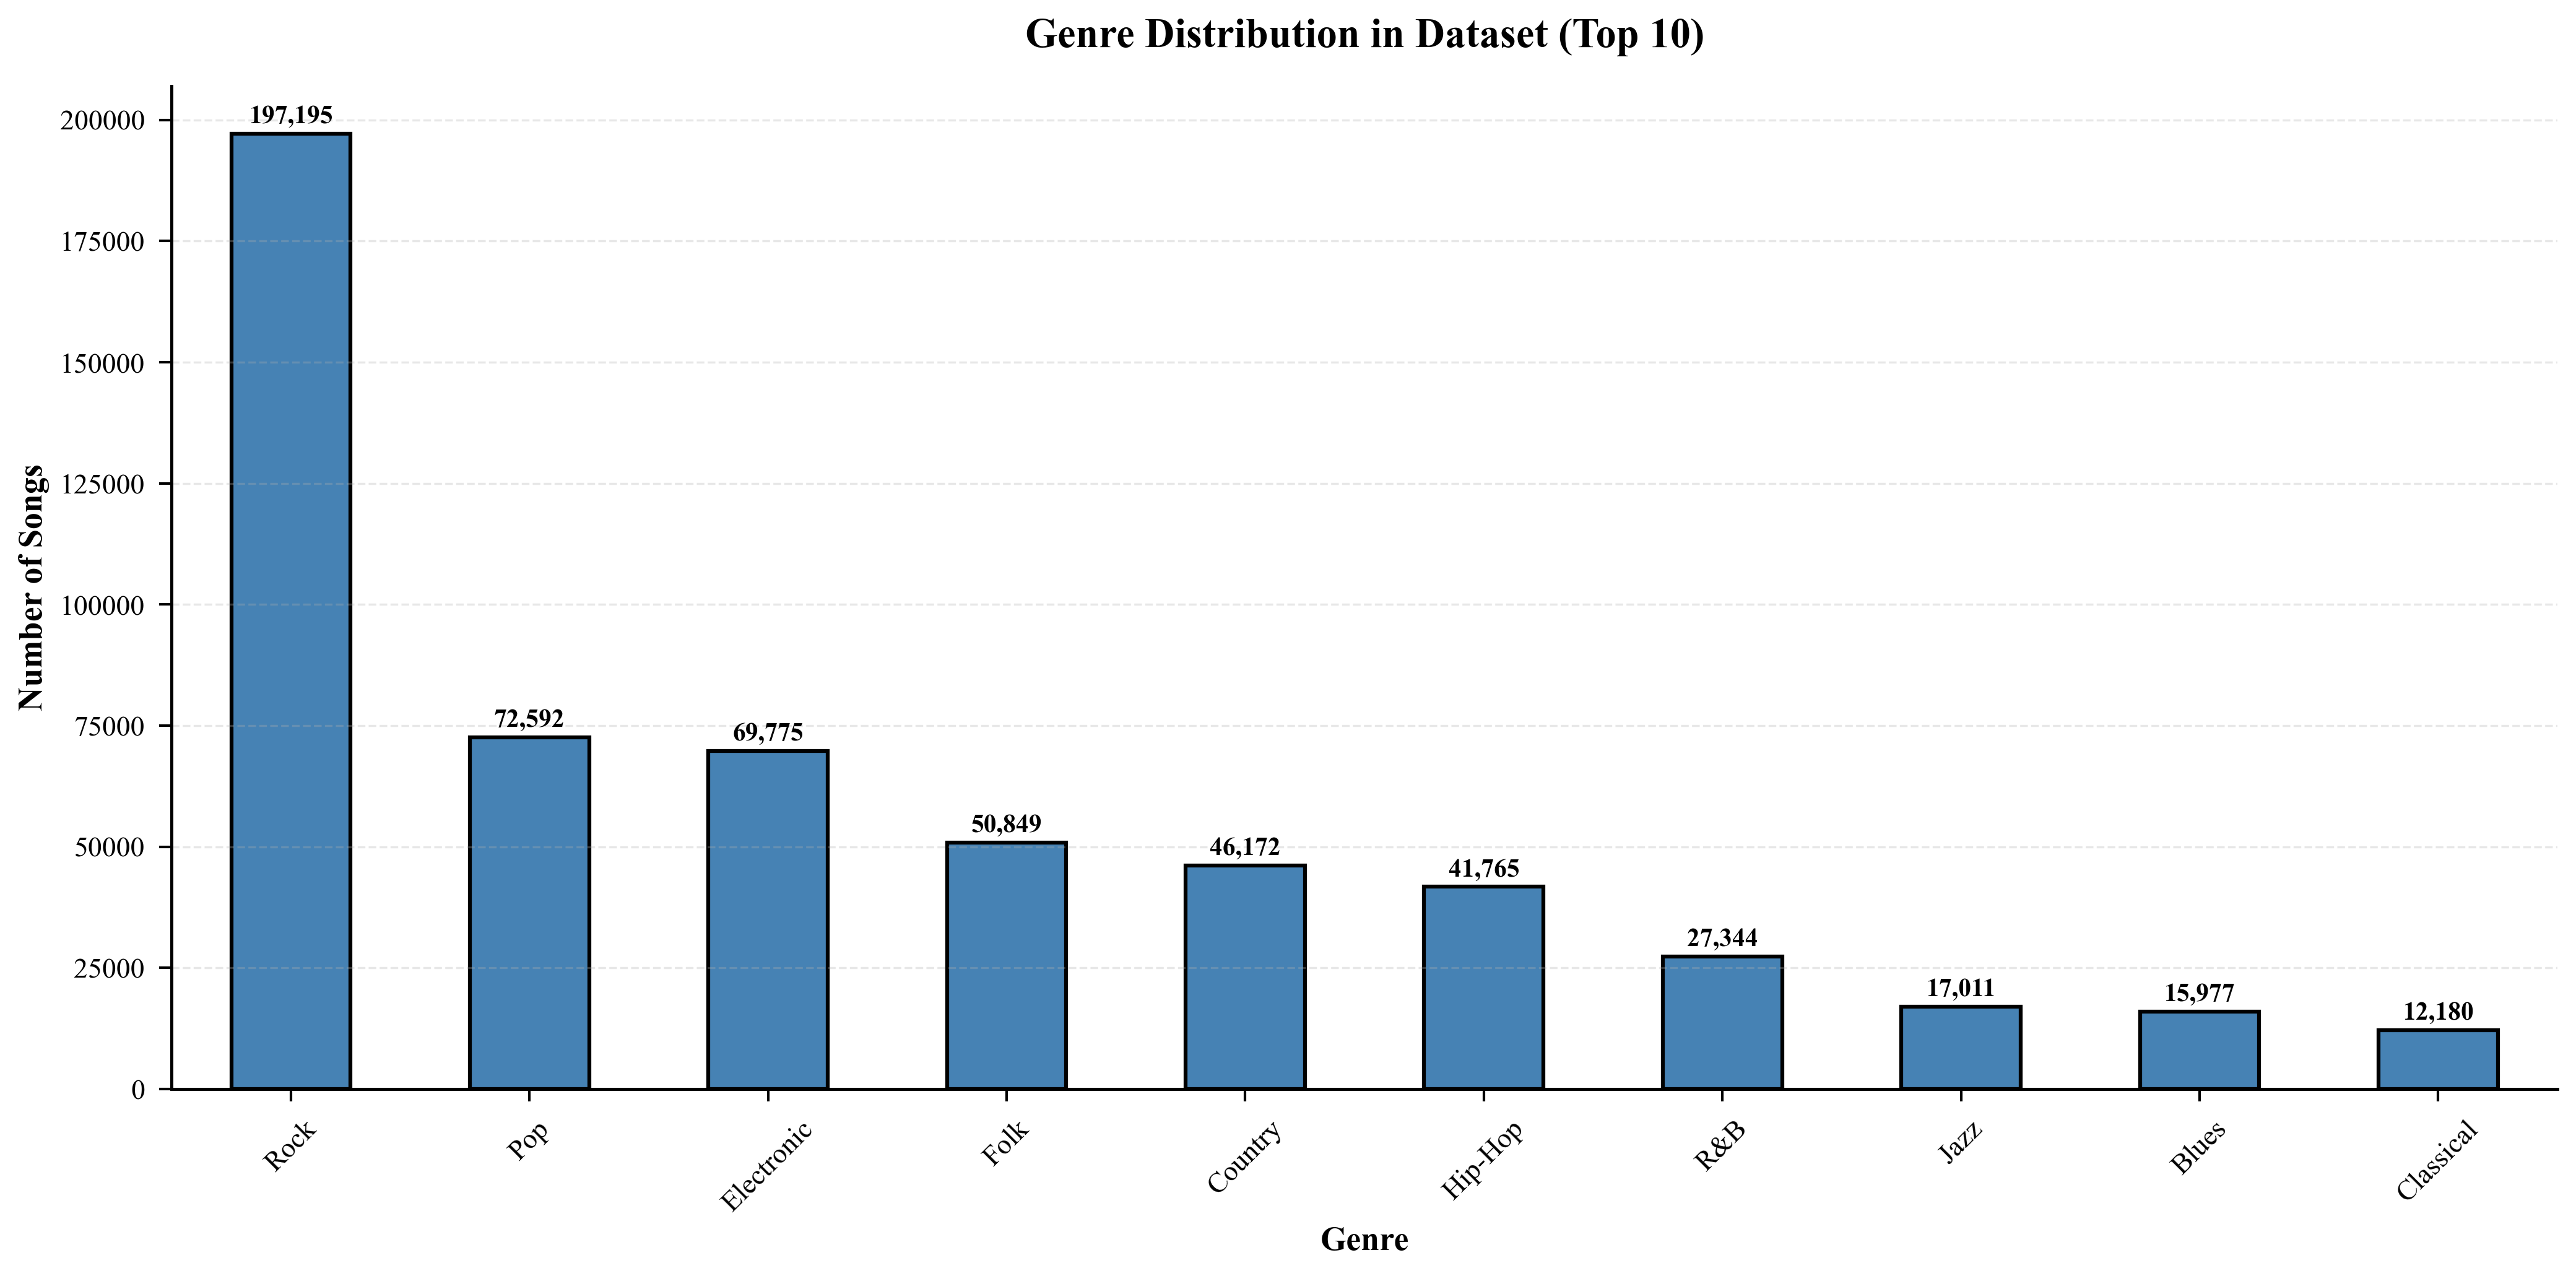

In [24]:
# Genre distribution - Academic style
genre_counts = df['genre'].value_counts()

print(f"Total unique genres: {len(genre_counts)}")
print(f"\nTop 10 genres:")
print(genre_counts.head(10))

# Visualize top 10 genres
fig, ax = plt.subplots(figsize=(14, 7))
bars = genre_counts.head(10).plot(kind='bar', color='steelblue', edgecolor='black', 
                                   linewidth=1.5, ax=ax)

ax.set_title('Genre Distribution in Dataset (Top 10)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Genre', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Songs', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on bars
for i, (idx, value) in enumerate(genre_counts.head(10).items()):
    ax.text(i, value + 1000, f'{value:,}', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/eda/genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

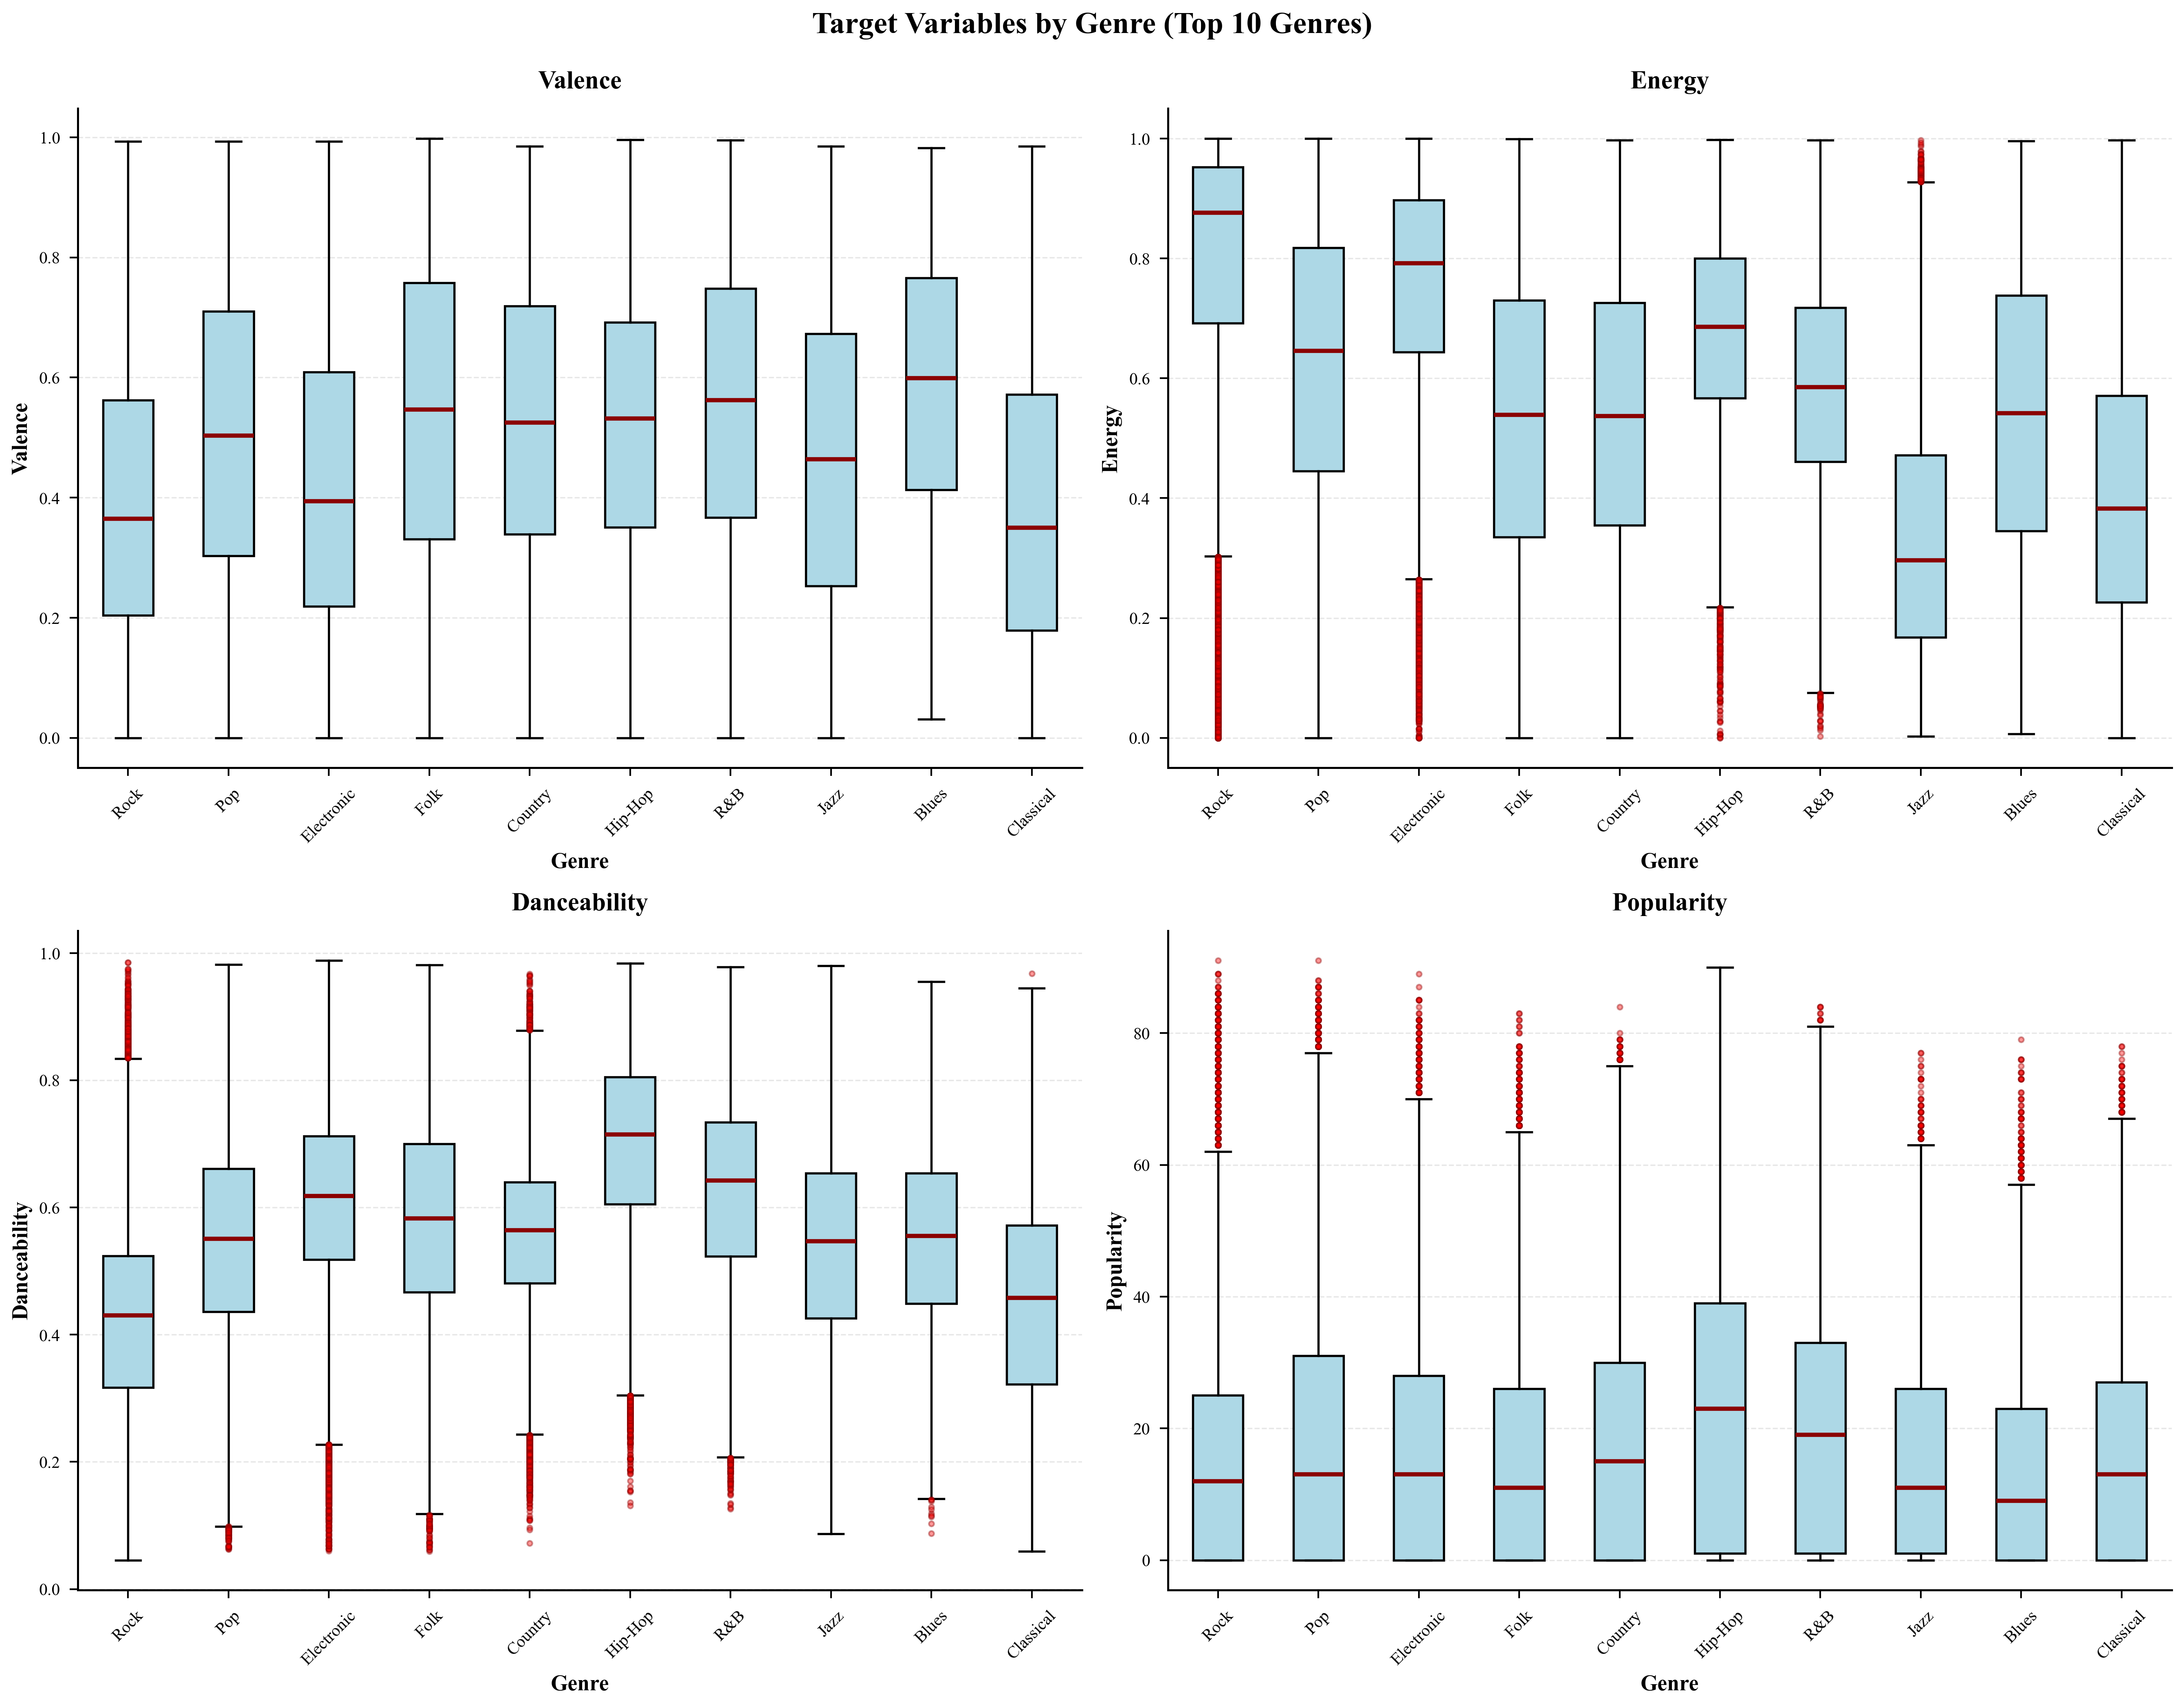

In [25]:
# Target variables by top genres - Academic style
top_genres = genre_counts.head(10).index
df_top_genres = df[df['genre'].isin(top_genres)]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Target Variables by Genre (Top 10 Genres)', fontsize=18, fontweight='bold', y=0.995)

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data for box plot
    data_by_genre = [df_top_genres[df_top_genres['genre'] == g][target].dropna() 
                     for g in top_genres]
    
    # Box plot with academic styling
    bp = ax.boxplot(data_by_genre, labels=top_genres, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.3),
                    medianprops=dict(color='darkred', linewidth=2.5),
                    whiskerprops=dict(color='black', linewidth=1.3),
                    capprops=dict(color='black', linewidth=1.3),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, 
                                   alpha=0.4, markeredgecolor='darkred'))
    
    ax.set_xlabel('Genre', fontsize=13, fontweight='bold')
    ax.set_ylabel(target.capitalize(), fontsize=13, fontweight='bold')
    ax.set_title(f'{target.capitalize()}', fontsize=15, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/eda/targets_by_genre.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Mean target values by genre
genre_means = df.groupby('genre')[target_vars].mean().sort_values('valence', ascending=False)

print("\nTop 5 Happiest Genres (by valence):")
print(genre_means.head(5).round(3))

print("\nTop 5 Saddest Genres (by valence):")
print(genre_means.tail(5).round(3))


Top 5 Happiest Genres (by valence):
         valence  energy  danceability  popularity
genre                                             
Blues      0.585   0.539         0.550      13.465
R&B        0.555   0.585         0.624      20.414
Folk       0.542   0.535         0.580      15.127
Country    0.530   0.537         0.557      17.914
Hip-Hop    0.519   0.678         0.698      23.831

Top 5 Saddest Genres (by valence):
            valence  energy  danceability  popularity
genre                                                
Pop           0.507   0.619         0.544      17.868
Jazz          0.471   0.337         0.536      15.304
Electronic    0.426   0.750         0.609      16.627
Rock          0.398   0.796         0.424      15.408
Classical     0.391   0.409         0.449      16.314


## 7. Year Analysis
### How has music evolved over time?

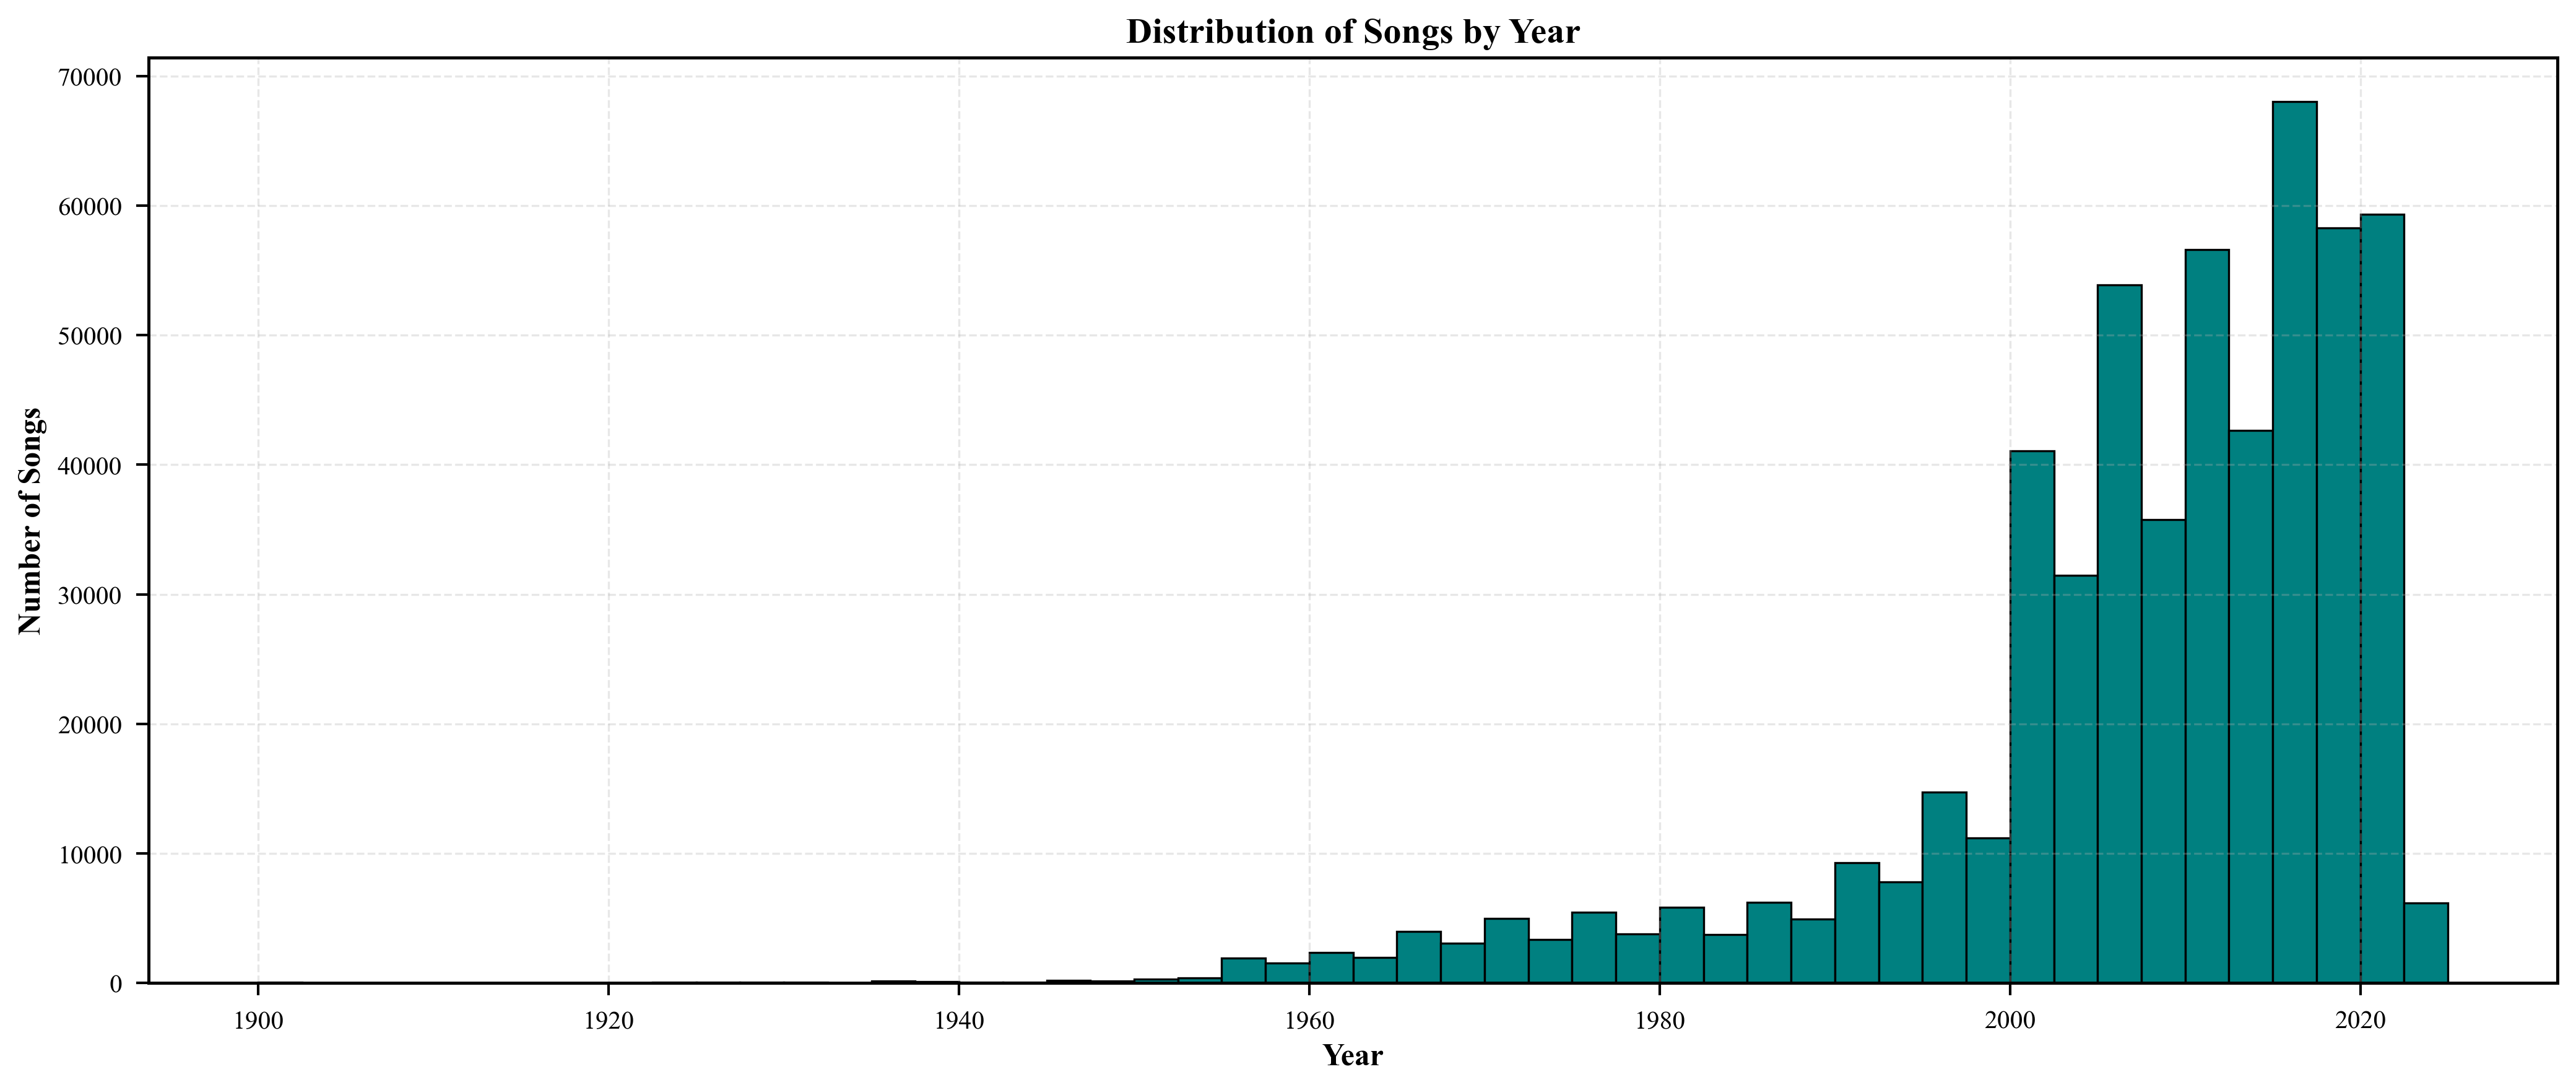

Year range: 1900 - 2025
Median year: 2010.0
Mean year: 2007.1


In [27]:
# Year distribution
plt.figure(figsize=(14, 6))
df['year'].hist(bins=50, edgecolor='black', color='teal')
plt.title('Distribution of Songs by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Year range: {df['year'].min()} - {df['year'].max()}")
print(f"Median year: {df['year'].median()}")
print(f"Mean year: {df['year'].mean():.1f}")

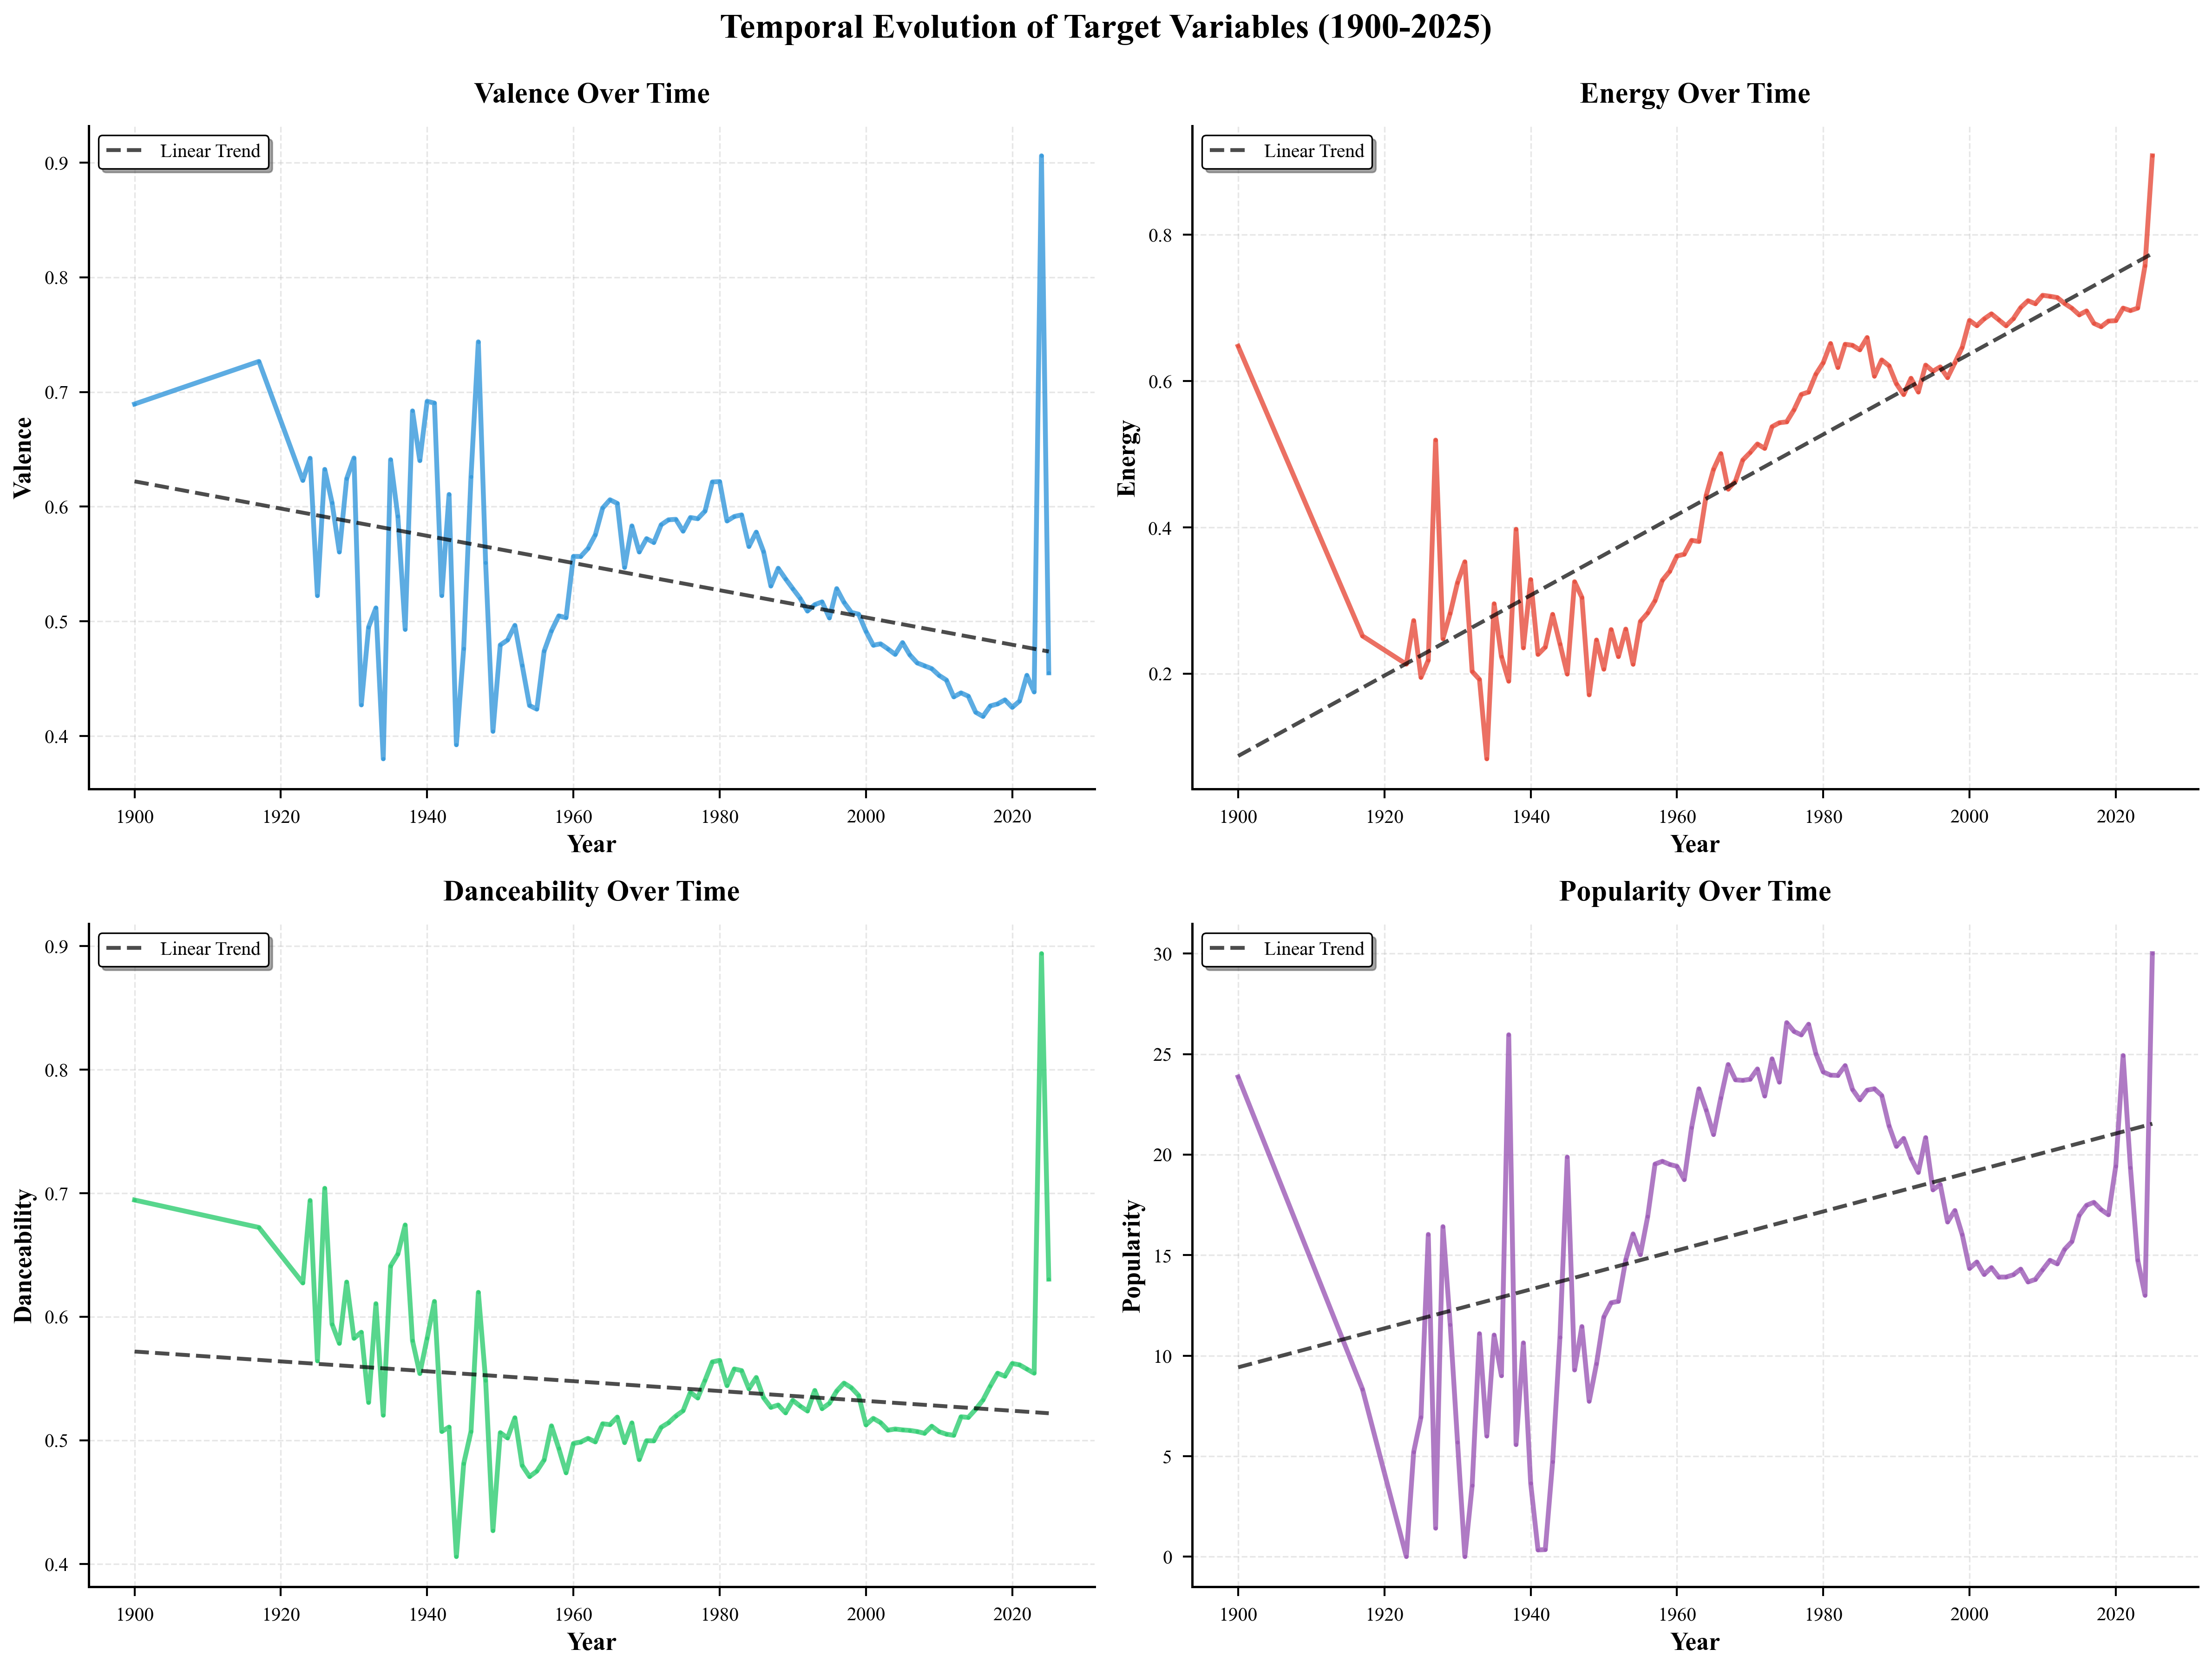

In [28]:
# Target trends over time - Academic style
# Group by year and calculate means
year_trends = df.groupby('year')[target_vars].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Temporal Evolution of Target Variables (1900-2025)', 
             fontsize=18, fontweight='bold', y=0.995)

colors_map = {'valence': '#3498db', 'energy': '#e74c3c', 
              'danceability': '#2ecc71', 'popularity': '#9b59b6'}

for idx, target in enumerate(target_vars):
    ax = axes[idx // 2, idx % 2]
    
    # Line plot with markers
    ax.plot(year_trends.index, year_trends[target], linewidth=2.5, 
            color=colors_map[target], marker='o', markersize=2, alpha=0.8)
    
    # Add trend line
    z = np.polyfit(year_trends.index, year_trends[target], 1)
    p = np.poly1d(z)
    ax.plot(year_trends.index, p(year_trends.index), "--", 
            color='black', linewidth=2, alpha=0.7, label='Linear Trend')
    
    ax.set_xlabel('Year', fontsize=13, fontweight='bold')
    ax.set_ylabel(target.capitalize(), fontsize=13, fontweight='bold')
    ax.set_title(f'{target.capitalize()} Over Time', fontsize=15, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', frameon=True, shadow=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/eda/temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Lyrics Analysis
### Basic text statistics

In [29]:
# Lyrics availability
has_lyrics = df['lyrics'].notna() & (df['lyrics'].str.strip() != '')

# Check if lyrics length is less than song name length (likely invalid)
invalid_lyrics = has_lyrics & (df['lyrics'].str.strip().str.len() < df['name'].str.len() * 4)

# Update has_lyrics to exclude invalid lyrics
has_lyrics = has_lyrics & ~invalid_lyrics

print(f"Songs with valid lyrics: {has_lyrics.sum():,} ({has_lyrics.sum()/len(df)*100:.2f}%)")
print(f"Songs without lyrics: {(~has_lyrics).sum():,} ({(~has_lyrics).sum()/len(df)*100:.2f}%)")
print(f"  - Invalid lyrics (shorter than song name): {invalid_lyrics.sum():,}")

Songs with valid lyrics: 549,906 (99.83%)
Songs without lyrics: 954 (0.17%)
  - Invalid lyrics (shorter than song name): 954


In [30]:
# Basic lyrics statistics (on a sample to avoid memory issues)
sample_size = min(10000, has_lyrics.sum())
df_with_lyrics = df[has_lyrics].sample(n=sample_size, random_state=42)

# Calculate basic stats
df_with_lyrics['word_count'] = df_with_lyrics['lyrics'].str.split().str.len()
df_with_lyrics['char_count'] = df_with_lyrics['lyrics'].str.len()

print(f"\nLyrics Statistics (sample of {sample_size:,} songs):")
print(df_with_lyrics[['word_count', 'char_count']].describe().round(1))


Lyrics Statistics (sample of 10,000 songs):
       word_count  char_count
count     10000.0     10000.0
mean        267.8      1384.1
std         208.1      1069.7
min           8.0        54.0
25%         153.0       799.0
50%         221.0      1146.0
75%         314.0      1615.2
max        3465.0     18450.0


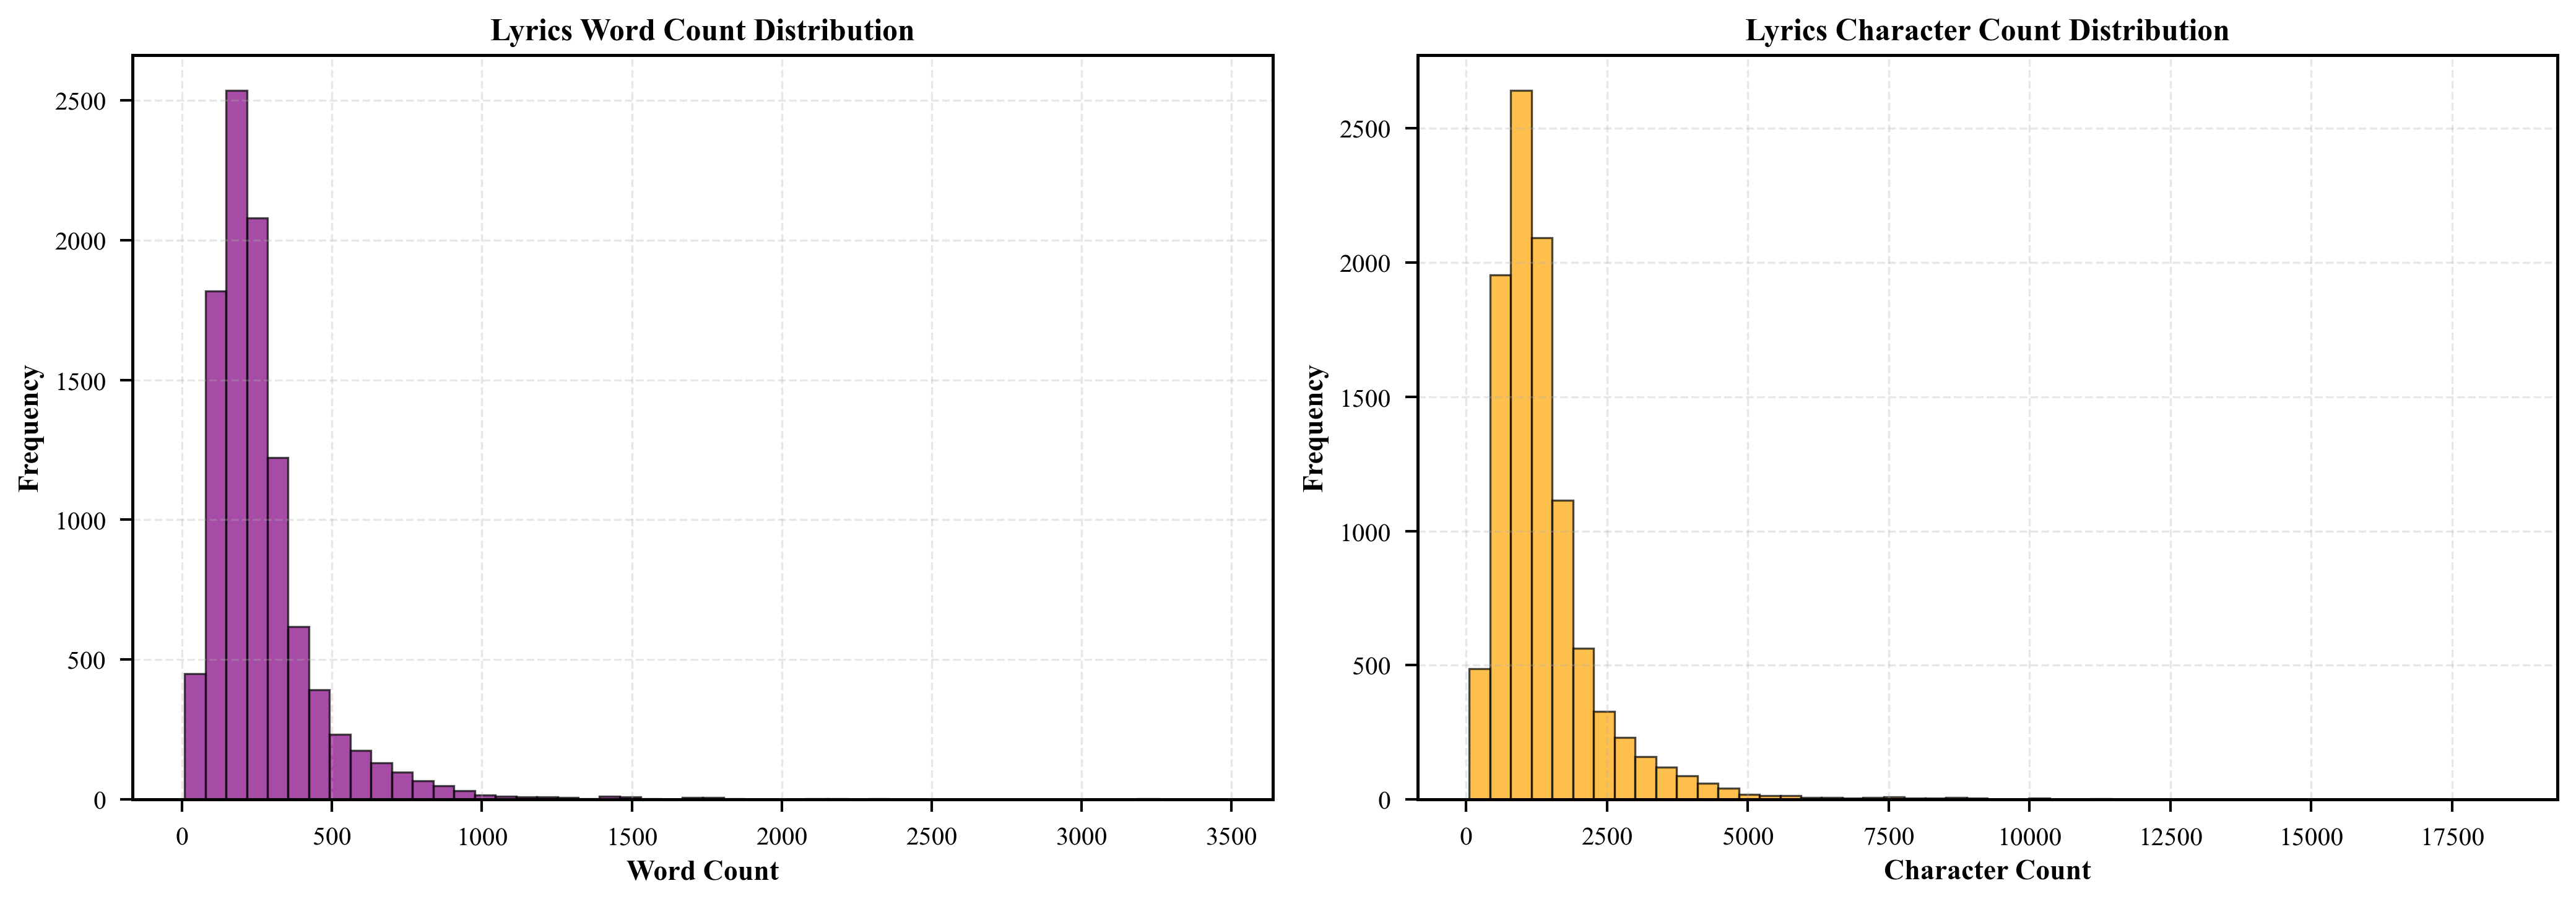

In [31]:
# Lyrics length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_with_lyrics['word_count'], bins=50, edgecolor='black', color='purple', alpha=0.7)
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Lyrics Word Count Distribution', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(df_with_lyrics['char_count'], bins=50, edgecolor='black', color='orange', alpha=0.7)
axes[1].set_xlabel('Character Count', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Lyrics Character Count Distribution', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Artist Analysis

Total unique artists: 78,676

Top 20 artists by song count:
artists
['Various Artists']       2453
Grateful Dead             1307
['Aretha Franklin']       1067
['Bob Dylan']              981
['Elvis Presley']          822
['Fleetwood Mac']          704
['Dolly Parton']           684
Elvis Presley              672
['Johnny Cash']            670
['Frank Sinatra']          613
['Emmylou Harris']         518
['The Fall']               513
['Willie Nelson']          504
['Barry Manilow']          503
Vybz Kartel                495
['The Rolling Stones']     484
Glee Cast                  471
['Al Jarreau']             448
['Guided By Voices']       432
['Alice Cooper']           428
Name: count, dtype: int64


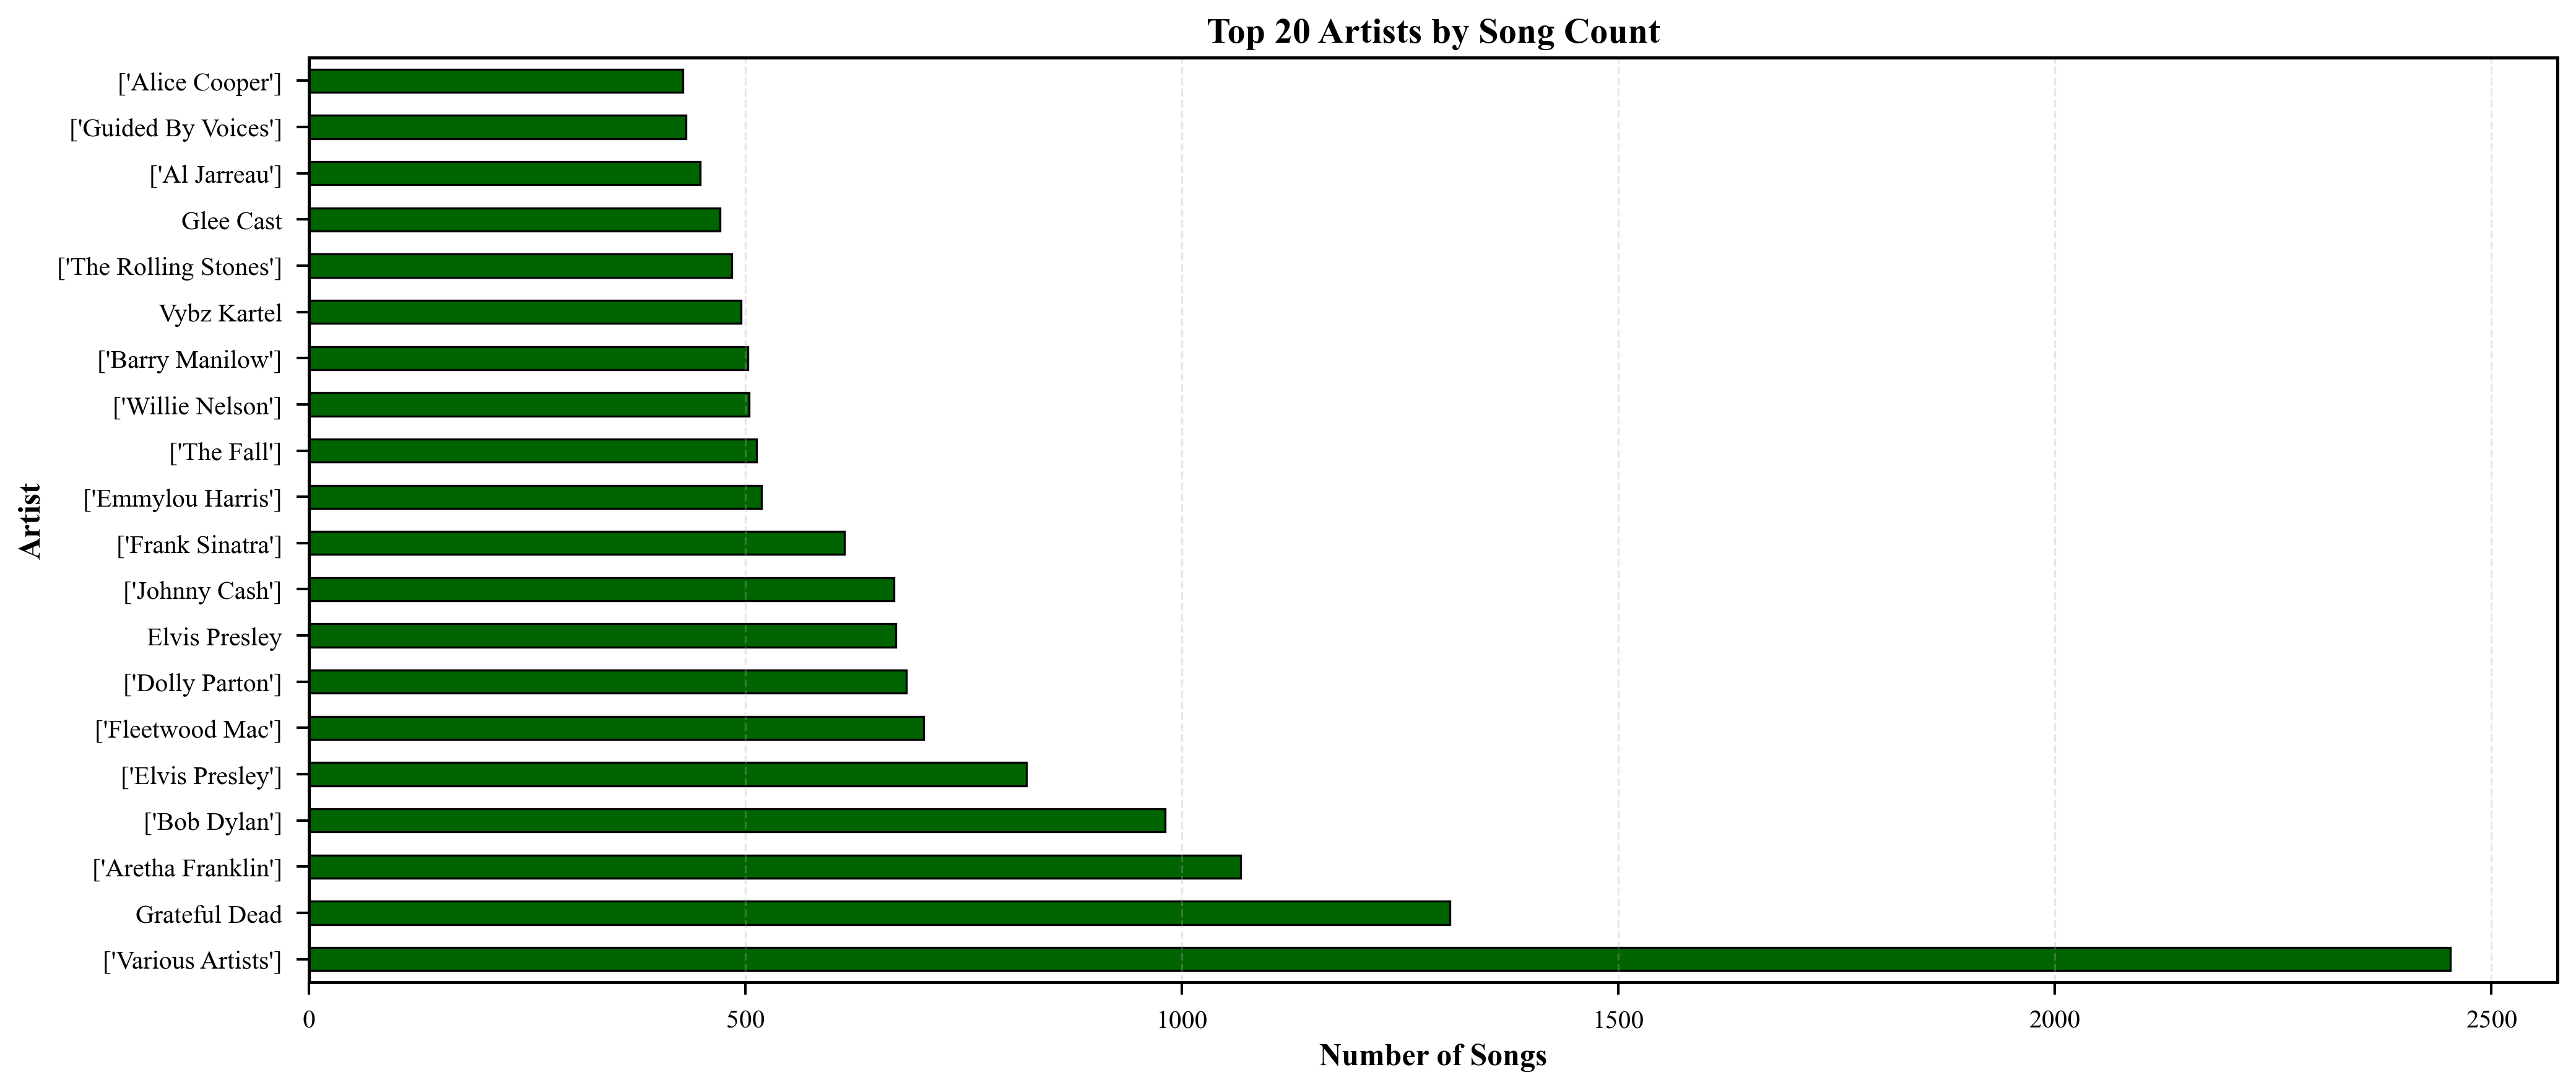


Artist Distribution:
  Artists with 1 song: 40,530
  Artists with 2-5 songs: 20,077
  Artists with 6-10 songs: 6,652
  Artists with >10 songs: 11,417


In [32]:
# Artist distribution
artist_counts = df['artists'].value_counts()

print(f"Total unique artists: {len(artist_counts):,}")
print(f"\nTop 20 artists by song count:")
print(artist_counts.head(20))

# Visualize
plt.figure(figsize=(14, 6))
artist_counts.head(20).plot(kind='barh', color='darkgreen', edgecolor='black')
plt.title('Top 20 Artists by Song Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Songs', fontsize=12)
plt.ylabel('Artist', fontsize=12)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Artist distribution stats
print(f"\nArtist Distribution:")
print(f"  Artists with 1 song: {(artist_counts == 1).sum():,}")
print(f"  Artists with 2-5 songs: {((artist_counts >= 2) & (artist_counts <= 5)).sum():,}")
print(f"  Artists with 6-10 songs: {((artist_counts >= 6) & (artist_counts <= 10)).sum():,}")
print(f"  Artists with >10 songs: {(artist_counts > 10).sum():,}")

## 10. Key Insights & Next Steps

In [33]:
print("="*80)
print("KEY INSIGHTS FROM EDA")
print("="*80)

print("\n📊 DATASET SUMMARY:")
print(f"  - Total songs: {len(df):,}")
print(f"  - Unique artists: {df['artists'].nunique():,}")
print(f"  - Unique genres: {df['genre'].nunique():,}")
print(f"  - Year range: {df['year'].min()} - {df['year'].max()}")
print(f"  - Songs with lyrics: {has_lyrics.sum():,} ({has_lyrics.sum()/len(df)*100:.1f}%)")

print("\n🎯 TARGET VARIABLES:")
for target in target_vars:
    print(f"  - {target.capitalize():15s}: Mean={df[target].mean():.3f}, Std={df[target].std():.3f}, Range=[{df[target].min():.3f}, {df[target].max():.3f}]")

print("\n🔗 TOP CORRELATIONS WITH TARGETS:")
for target in target_vars:
    target_corr = df[audio_features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
    top_feature = target_corr.index[0]
    top_value = target_corr.iloc[0]
    print(f"  - {target.capitalize():15s}: {top_feature} (r={top_value:.3f})")

print("\n" + "="*80)
print("NEXT STEPS")
print("="*80)
print("1. ✅ Create artist-aware train/val/test splits (prevent data leakage)")
print("2. ✅ Scale audio features (StandardScaler)")
print("3. ✅ Train baseline models (Mean, Linear, Ridge, XGBoost)")
print("4. ⏸️  Evaluate baseline performance")
print("5. ⏸️  Add text features if needed")
print("="*80)

KEY INSIGHTS FROM EDA

📊 DATASET SUMMARY:
  - Total songs: 550,860
  - Unique artists: 78,676
  - Unique genres: 10
  - Year range: 1900 - 2025
  - Songs with lyrics: 549,906 (99.8%)

🎯 TARGET VARIABLES:
  - Valence        : Mean=0.465, Std=0.249, Range=[0.000, 0.998]
  - Energy         : Mean=0.671, Std=0.246, Range=[0.000, 1.000]
  - Danceability   : Mean=0.527, Std=0.173, Range=[0.045, 0.988]
  - Popularity     : Mean=16.918, Std=16.957, Range=[0.000, 91.000]

🔗 TOP CORRELATIONS WITH TARGETS:
  - Valence        : Mean=0.465, Std=0.249, Range=[0.000, 0.998]
  - Energy         : Mean=0.671, Std=0.246, Range=[0.000, 1.000]
  - Danceability   : Mean=0.527, Std=0.173, Range=[0.045, 0.988]
  - Popularity     : Mean=16.918, Std=16.957, Range=[0.000, 91.000]

🔗 TOP CORRELATIONS WITH TARGETS:
  - Valence        : duration_ms (r=0.206)
  - Energy         : loudness (r=0.777)
  - Valence        : duration_ms (r=0.206)
  - Energy         : loudness (r=0.777)
  - Danceability   : instrumentalnes

## 📝 Observations to Document

**Fill this in after running the notebook:**

1. **Target Distribution:**
   - Are targets balanced or skewed?
   - Any unusual patterns?

2. **Feature Correlations:**
   - Which features correlate strongly with each target?
   - Any multicollinearity issues?

3. **Genre Patterns:**
   - Do certain genres have distinct target values?
   - Genre imbalance?

4. **Temporal Trends:**
   - How have music characteristics changed over time?
   - Any era-specific patterns?

5. **Data Quality:**
   - Any remaining issues?
   - Features that need special handling?